# Credit Risk PD Model — FinVista Consumer Lending

**Tram Nguyen** &nbsp;·&nbsp; Data Science Case Study &nbsp;·&nbsp; July 2026

## Overview

FinVista is a UK consumer lender whose five-year-old rules-based credit scorecard has degraded: the default rate on new loans has climbed from 7% to over 10% over the past 18 months, costing an estimated £4.2M in unexpected credit losses. This notebook builds a machine-learning probability-of-default (PD) model to replace that scorecard, covering the full pipeline from raw data to a deployment-ready artefact:

- Exploratory analysis of four source tables (customers, credit history, loans, transactions) to understand data quality, distributions, and default drivers
- Point-in-time feature engineering (avoiding target leakage) including Weight-of-Evidence encoding and 17 domain-driven ratio and interaction features
- Two candidate models — Logistic Regression and XGBoost — trained and compared on a held-out validation set
- Translation of model output into a lending policy, quantifying Expected Loss reduction at the business's mandated 70% approval rate
- A monitoring plan for input and target drift once the model is in production

**Headline result:** the selected Logistic Regression model reduces Expected Loss by **84%** at the required 70% approval rate (validation Gini = 0.646), against a business target of ≥25%.


## 1. Business Problem & Modelling Approach

FinVista must decide, at the point of application, whether to approve or reject each personal loan (£2,000–£50,000, 1–5 year terms). Approving an applicant who later defaults costs the business directly — the pound amount actually lost (`loss_given_default`) — while rejecting a good applicant only forgoes that one loan's interest margin. The task is therefore a **binary classification** problem: predict `default_flag` (0 = repaid, 1 = defaulted) for each loan application, where **one row represents one loan application, not one customer** — a customer can submit more than one application over time, and each must be scored independently on the information available at the time it was submitted.

**Why Gini, not accuracy.** With a ~10% default rate, a trivial model that predicts "no default" for everyone scores 90% accuracy while providing zero decision value. Gini (= 2×AUC − 1) instead measures how well the model *ranks* applicants from safest to riskiest, independent of the base rate or any chosen threshold — 0 means no better than random, 1 means perfect separation. This is the metric FinVista tracks internally, and the one used throughout this notebook.

**The cost asymmetry that shapes the objective.** Approving a future defaulter is far more costly to the bank than rejecting a good payer — Expected Loss is the sum, over *approved* loans, of `default_flag × loss_given_default`. Because FinVista is contractually required to approve at least 70% of applicants, it cannot simply raise the rejection bar to avoid that mistake; some marginal risk must always be accepted. Success is therefore defined as a **≥25% reduction in Expected Loss at a fixed 70% approval rate** — which means the model has to be excellent at ranking who, *within* that required 70%, is genuinely safest, not just at rejecting more people.

**Why the transaction data needs pre-aggregation.** `transactions` holds many rows per customer (one per purchase); `loans` holds one row per application. Joining them directly on `customer_id` would fan out each loan row once per matching transaction, corrupting every downstream statistic. Transactions must be aggregated to one row **per loan application** — using only transactions dated before that specific application — rather than one row per customer, otherwise a customer's second application would "see" transactions and outcomes that only happened around their first. This point-in-time aggregation is built in Section 4.

## 2. Data Loading & Overview

In [1]:
# Import libraries — add any others you need
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

# ML libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, RocCurveDisplay, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb
import joblib

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

RANDOM_STATE = 42
SNAPSHOT = pd.Timestamp('2026-06-20')
print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
import pandas as pd

# Load all tables
customers = pd.read_csv('data/customers.csv')
credit_history = pd.read_csv('data/credit_history.csv')
loans = pd.read_csv('data/loans.csv')
transactions = pd.read_csv('data/transactions.csv')

# Read columns
tables = {
    'Customers': customers,
    'Credit History': credit_history,
    'Loans': loans,
    'Transactions': transactions
}

# Preview data
for name, df in tables.items():
    print(f"=== Table: {name} ===")
    df.info()
    print("\n" + "="*50 + "\n")


=== Table: Customers ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         8000 non-null   object 
 1   date_of_birth       8000 non-null   object 
 2   age                 8000 non-null   int64  
 3   education           8000 non-null   object 
 4   employment_status   8000 non-null   object 
 5   annual_income       7666 non-null   float64
 6   housing_status      8000 non-null   object 
 7   months_at_address   7578 non-null   float64
 8   marital_status      8000 non-null   object 
 9   n_dependents        8000 non-null   int64  
 10  region              8000 non-null   object 
 11  months_as_customer  8000 non-null   int64  
dtypes: float64(2), int64(3), object(7)
memory usage: 750.1+ KB


=== Table: Credit History ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns

`customers` and `credit_history` both have 8,000 rows — one per customer, a 1:1 relationship, as expected. `loans` has 10,040 rows, more than the customer count, which is expected rather than a data quality problem: customers can submit multiple applications over time, a 1:many relationship that must be respected during aggregation later on, otherwise later loans would leak information about earlier ones and vice versa. `transactions` is the largest table by far (one row per purchase) and has no missing values. The row-count relationships are consistent with the data dictionary.

## 3. Exploratory Data Analysis

### 3.1 Data Quality


loans — missing values:
  loan_purpose                      192  (1.9 %)

customers — missing values:
  annual_income                     334  (4.2 %)
  months_at_address                 422  (5.3 %)

credit_history — missing values:
  credit_score                      252  (3.2 %)
  n_inquiries_12m                   390  (4.9 %)
  months_since_deliq              6,222  (77.8 %)

transactions — no missing values

Duplicate loan rows (same cust+date+amount): 82
      loan_id customer_id application_date  loan_amount
163  L0000164     C006070       2025-05-06         2000
192  L0000193     C005051       2025-02-23        10000
220  L0000221     C006308       2024-10-23        10000
727  L0000728     C001470       2023-08-30        30000

Loan customer_ids not in customers: 0
Txn  customer_ids not in customers: 0

Default rate: 1008/10040 = 10.0%


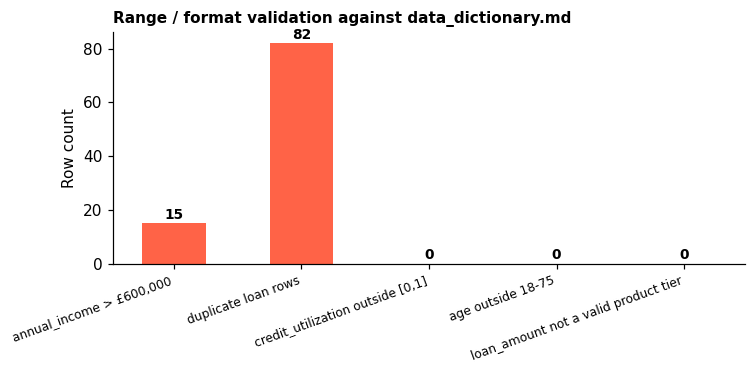

annual_income > £600,000 (documented plausible max): 15
duplicate loan rows (customer_id + application_date + loan_amount): 82
credit_utilization outside [0,1]: 0
age outside 18-75: 0
loan_amount not a valid product tier: 0


In [3]:
# ─── 3.1  DATA QUALITY ────────────────────────────────────────────────────

# 1. Missing values across all tables
print("=" * 55)
for name, df in [('loans', loans), ('customers', customers),
                 ('credit_history', credit_history), ('transactions', transactions)]:
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    pct  = (miss / len(df) * 100).round(1)
    if len(miss):
        print(f"\n{name} — missing values:")
        for col in miss.index:
            print(f"  {col:30s}  {miss[col]:5,}  ({pct[col]:.1f} %)")
    else:
        print(f"\n{name} — no missing values")

# 2. Duplicate loan applications
dup_mask = loans.duplicated(subset=['customer_id','application_date','loan_amount'], keep=False)
print(f"\nDuplicate loan rows (same cust+date+amount): {dup_mask.sum()}")
print(loans[dup_mask].head(4)[['loan_id','customer_id','application_date','loan_amount']])

# 3. Referential integrity: customer_id coverage
loans_ids = set(loans['customer_id'])
txn_ids   = set(transactions['customer_id'])
cust_ids  = set(customers['customer_id'])
print(f"\nLoan customer_ids not in customers: {len(loans_ids - cust_ids)}")
print(f"Txn  customer_ids not in customers: {len(txn_ids   - cust_ids)}")

# 4. Target distribution
total   = len(loans)
n_def   = loans['default_flag'].sum()
print(f"\nDefault rate: {n_def}/{total} = {n_def/total:.1%}")

# --- Range / allowed-value validation against data_dictionary.md ---
issues = {}
issues['annual_income > £600,000 (documented plausible max)'] = (customers['annual_income'] > 600_000).sum()
issues['duplicate loan rows (customer_id + application_date + loan_amount)'] = \
    loans.duplicated(subset=['customer_id','application_date','loan_amount'], keep=False).sum()
issues['credit_utilization outside [0,1]'] = ((credit_history['credit_utilization']<0)|(credit_history['credit_utilization']>1)).sum()
issues['age outside 18-75'] = ((customers['age']<18)|(customers['age']>75)).sum()
issues['loan_amount not a valid product tier'] = (~loans['loan_amount'].isin([2000,5000,10000,15000,20000,30000,50000])).sum()

fig, ax = plt.subplots(figsize=(7, 3.5))
labels = [k.split('(')[0].strip() for k in issues.keys()]
values = list(issues.values())
colors = ['tomato' if v > 0 else 'steelblue' for v in values]
bars = ax.bar(labels, values, color=colors, width=0.5)
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v + max(values)*0.02, str(v), ha='center', fontsize=9, fontweight='bold')
ax.set_title('Range / format validation against data_dictionary.md', fontweight='bold', loc='left', fontsize=10)
ax.set_ylabel('Row count')
plt.xticks(rotation=20, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

for k, v in issues.items():
    print(f"{k}: {v}")


**Findings**

*Missing values:*
- Customers: `annual_income` (334 missing, 4.2%), `months_at_address` (422 missing, 5.3%)
- Credit History: `credit_score` (252 missing, 3.2%), `n_inquiries_12m` (390 missing, 4.9%), `months_since_deliq` (6,222 missing, 77.8% — informative, not an error: it means "never delinquent")
- Loans: `loan_purpose` (192 missing, 1.9%)
- Transactions: no missing values

*Data quality strengths:*
- 82 duplicate loan applications found (same customer + application date + loan amount)
- All customer IDs in `loans` and `transactions` exist in `customers` (referential integrity intact)
- Default rate is 10.0% (1,008 defaults out of 10,040 loans) — a manageable class imbalance

*Range validation against the data dictionary:* 15 `annual_income` values exceed the documented plausible maximum of £600,000 (up to £2.83M) — almost certainly data-entry errors rather than natural outliers; these are capped in Section 4. All other numeric ranges and categorical values elsewhere in `customers`/`credit_history`/`loans` conform to the dictionary.

**Handling strategy carried into Section 4:**
1. Drop `credit_score` nulls (3.2%) — credit score is too critical for risk assessment to impute reliably.
2. Impute `annual_income` with the median by `employment_status`; impute `months_at_address` with the median by region; fill `n_inquiries_12m` with 0; fill `loan_purpose` with an explicit `unknown` category.
3. Convert `months_since_deliq` into a binary `has_delinquency_24m` flag rather than imputing a numeric value, since the missingness itself is structural, not random.
4. Remove duplicate applications, keeping the first occurrence per customer–date–amount combination.

### 3.2 Distributions

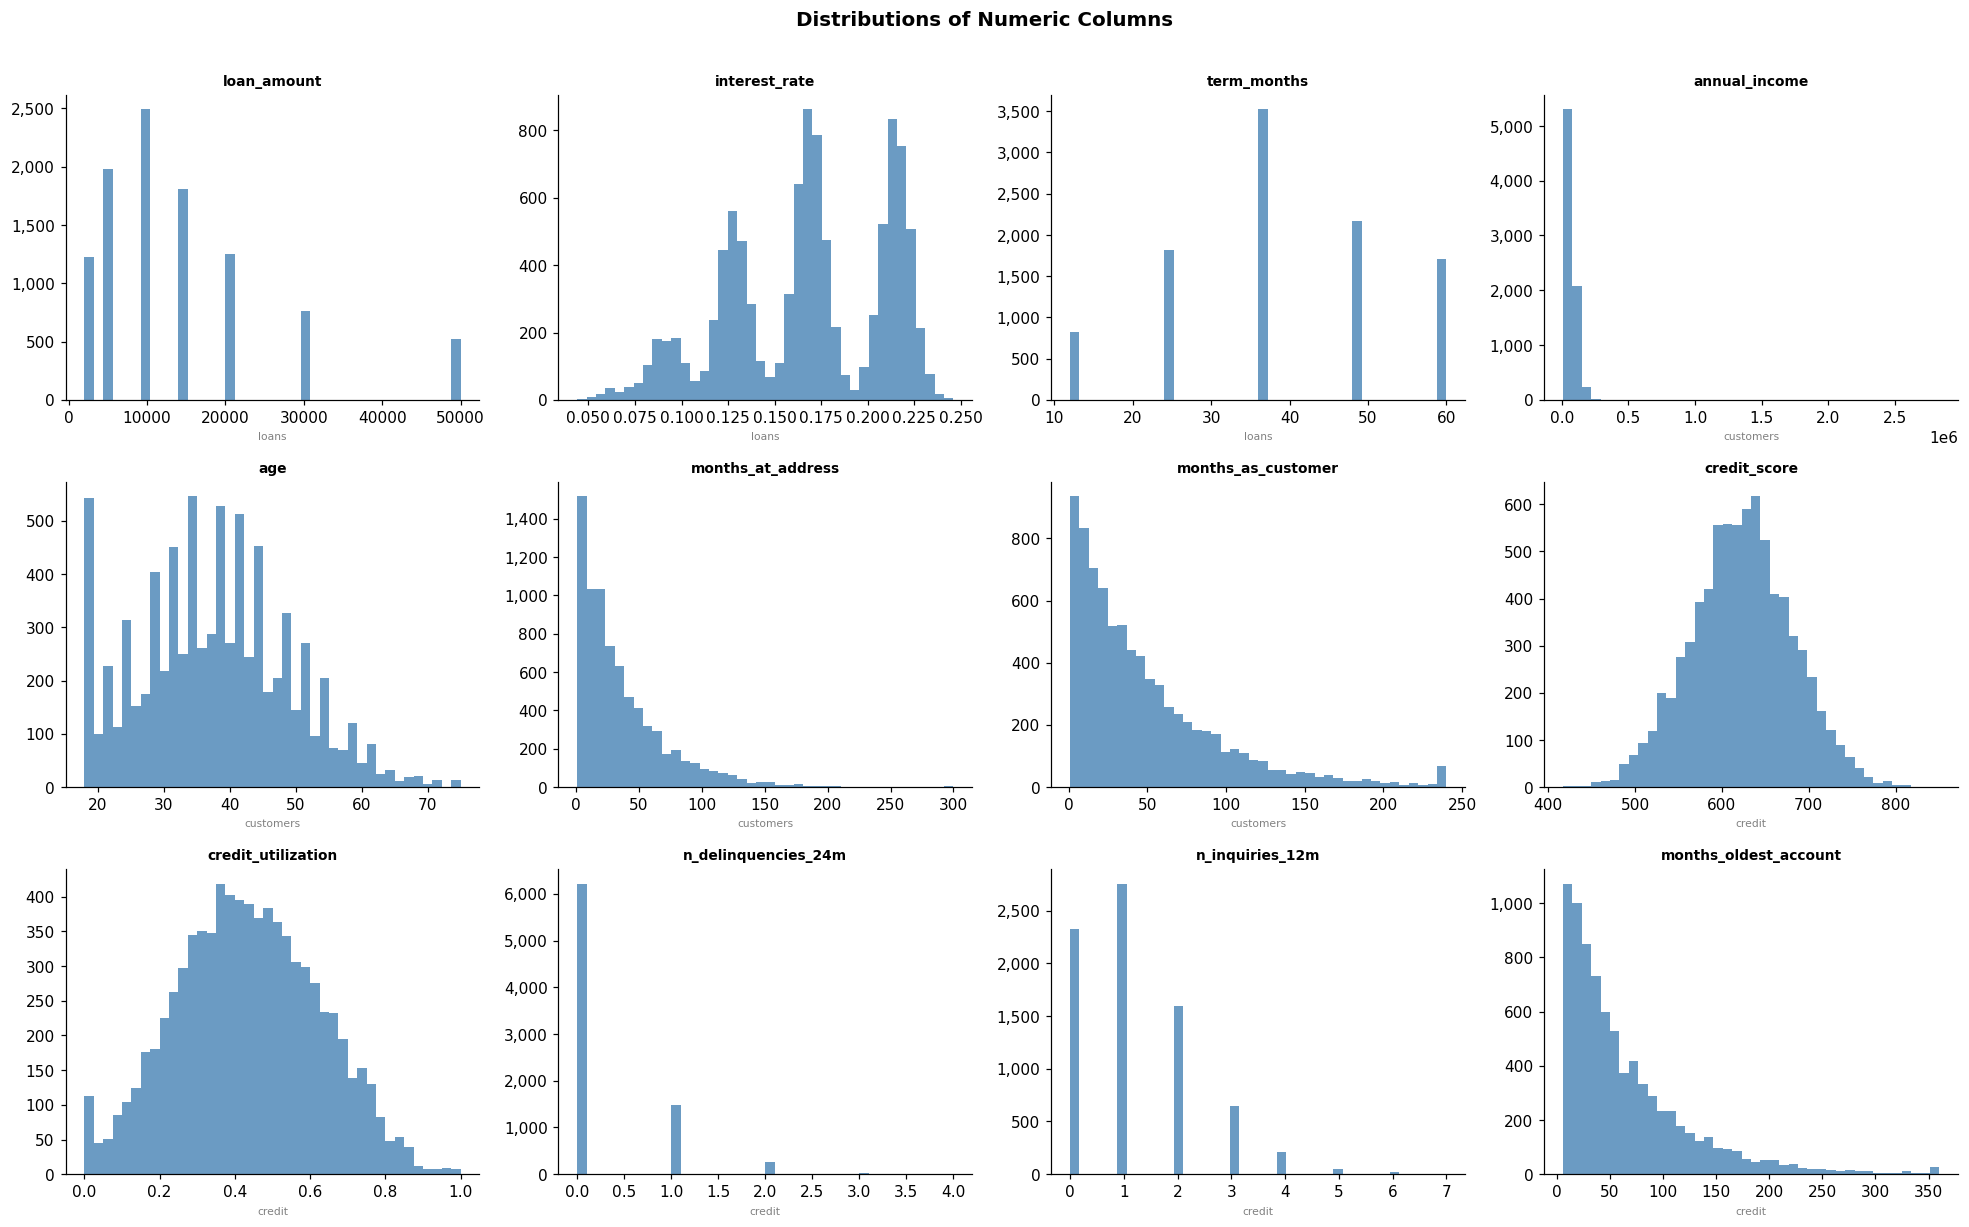

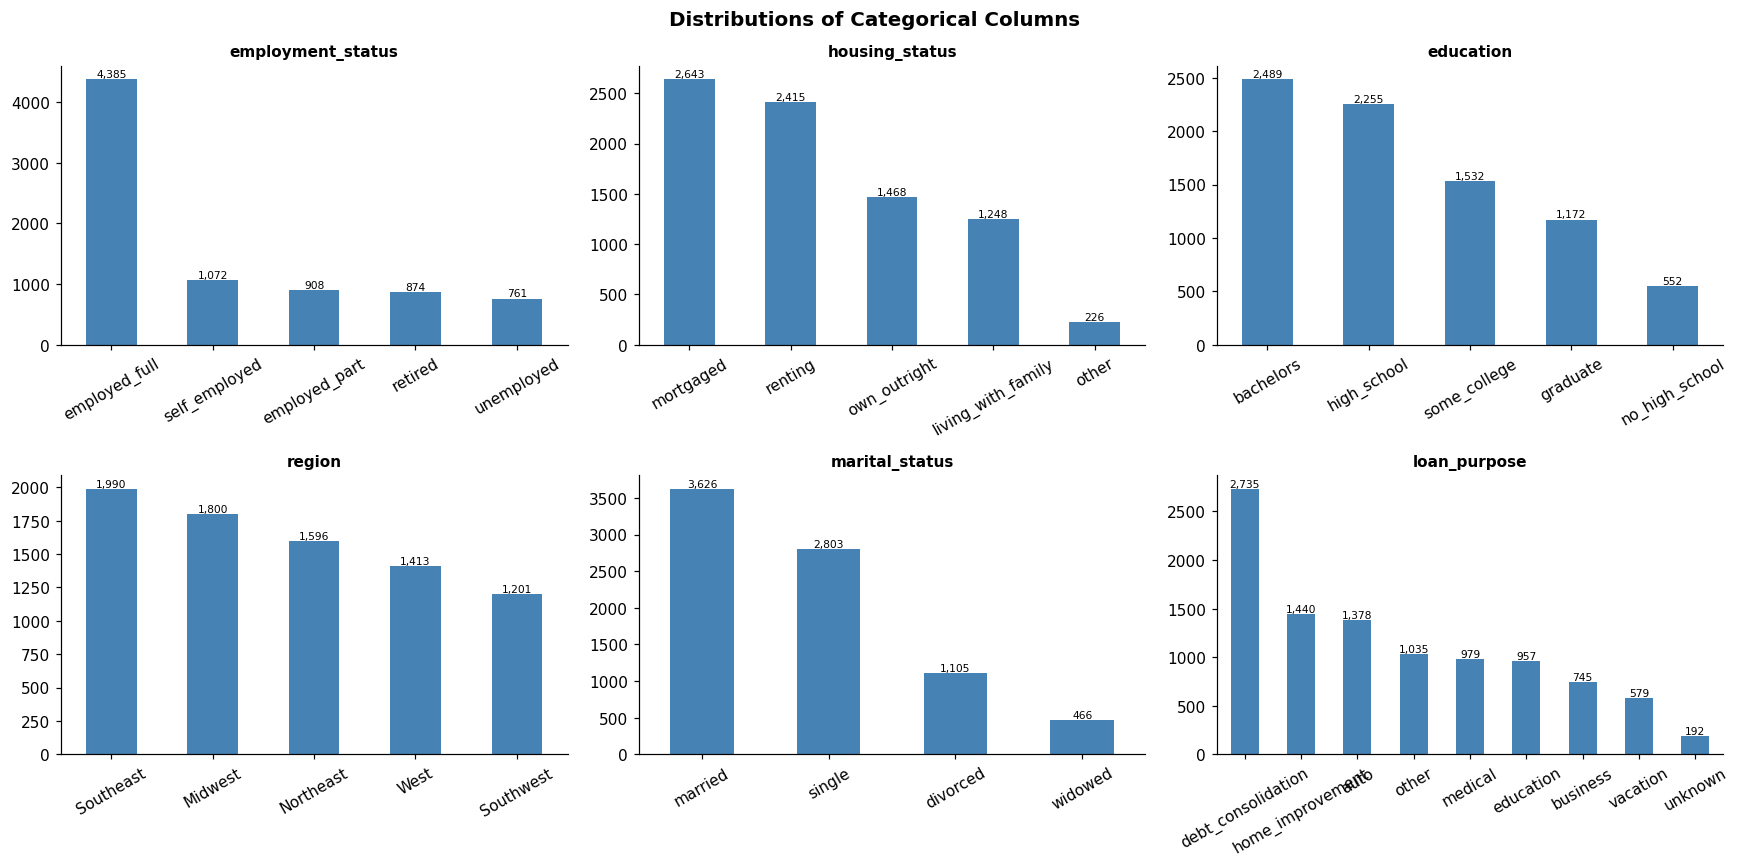

In [4]:
# ─── 3.2  DISTRIBUTIONS ──────────────────────────────────────────────────

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()

# Numeric columns from loans + customers + credit
num_cols = [
    ('loans',     'loan_amount',       loans),
    ('loans',     'interest_rate',     loans),
    ('loans',     'term_months',       loans),
    ('customers', 'annual_income',     customers),
    ('customers', 'age',               customers),
    ('customers', 'months_at_address', customers),
    ('customers', 'months_as_customer',customers),
    ('credit',    'credit_score',      credit_history),
    ('credit',    'credit_utilization',credit_history),
    ('credit',    'n_delinquencies_24m',credit_history),
    ('credit',    'n_inquiries_12m',   credit_history),
    ('credit',    'months_oldest_account', credit_history),
]

for ax, (tbl, col, df) in zip(axes, num_cols):
    data = df[col].dropna()
    ax.hist(data, bins=40, color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_title(f'{col}', fontsize=9, fontweight='bold')
    ax.set_xlabel(tbl, fontsize=7, color='grey')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Distributions of Numeric Columns', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Categorical bar charts
cat_cols = [
    ('employment_status', customers),
    ('housing_status',    customers),
    ('education',         customers),
    ('region',            customers),
    ('marital_status',    customers),
    ('loan_purpose',      loans.assign(loan_purpose=loans.loan_purpose.fillna('unknown'))),
]

fig2, axes2 = plt.subplots(2, 3, figsize=(16, 8))
for ax, (col, df) in zip(axes2.flatten(), cat_cols):
    vc = df[col].value_counts()
    vc.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}',
                    (p.get_x()+p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=7)

plt.suptitle('Distributions of Categorical Columns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Key distributional findings:**

- **`annual_income`** is heavily right-skewed with a maximum above £2.8M (the 99th percentile is ~£193K). The extreme tail values are likely data entry errors and are capped in Section 4; a log transform is used for the logistic regression model.
- **`credit_score`** is roughly bell-shaped, centred around 623, consistent with a credit-active consumer population.
- **`credit_utilization`** is mildly right-skewed with a cluster near 1.0, indicating customers maxing out their credit.
- **`n_delinquencies_24m`** is zero-inflated — the vast majority of customers have 0 delinquencies, which motivates a binary `any_delinquency` flag.
- **`loan_purpose`**: `debt_consolidation` is the largest category (27%), already known to be the riskiest purpose.
- **`term_months`** and **`loan_amount`** are discrete product tiers rather than continuous variables, so their histograms are step functions.

### 3.3 Which Features Relate to Default?

Found 19 numeric features to analyze:
['loan_amount', 'term_months', 'interest_rate', 'loss_given_default', 'age', 'annual_income', 'months_at_address', 'n_dependents', 'months_as_customer', 'credit_score', 'n_open_accounts', 'total_credit_limit', 'credit_utilization', 'months_oldest_account', 'n_delinquencies_24m', 'n_public_records', 'n_inquiries_12m', 'months_since_deliq', 'mortgage_balance']


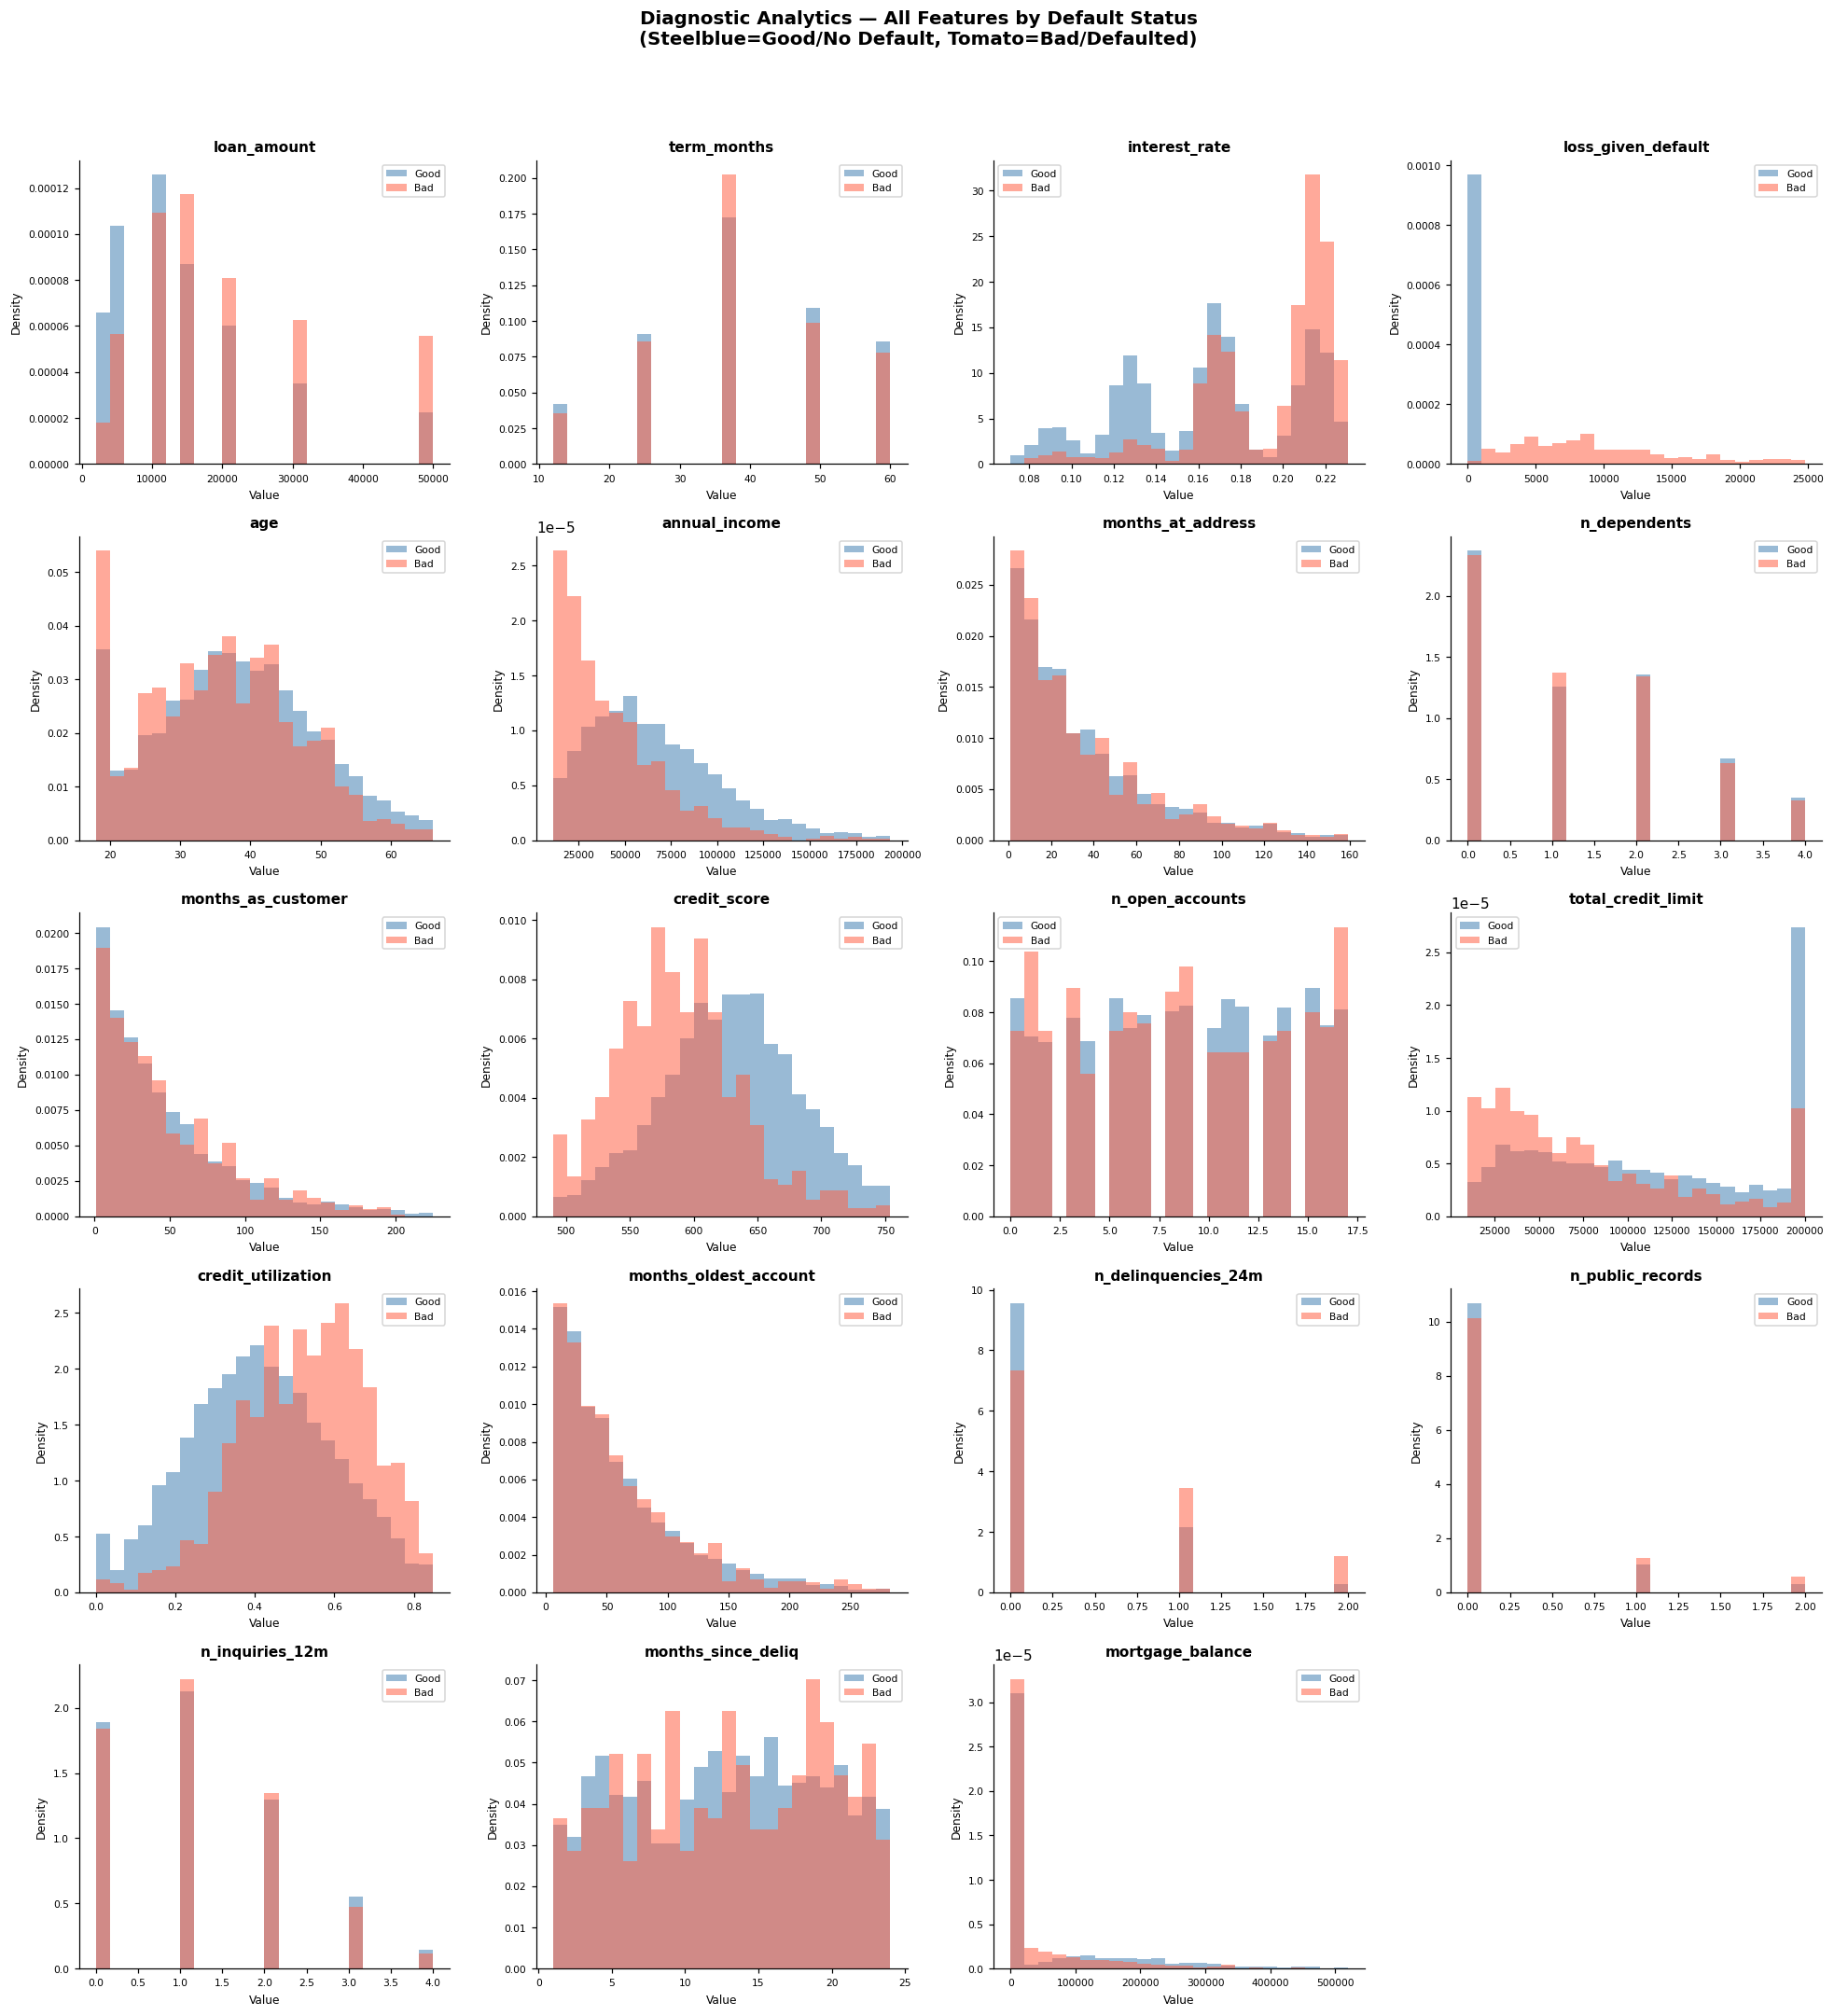


FEATURE ANALYSIS GUIDE:
STRONG PREDICTORS: Distributions barely overlap (clear separation)
WEAK PREDICTORS: Distributions overlap heavily (similar shapes)


In [5]:
# ── 3.3 Diagnostic — Which features drive default? ──────────────────────────

# First, join all tables to get a single dataset with both features and the target
df_analysis = (
    loans.merge(customers, on='customer_id', how='left')
    .merge(credit_history, on='customer_id', how='left')
)

# Get all numeric columns (excluding IDs, dates, target, and redundant records)
exclude_cols = {'loan_id', 'customer_id', 'app_date', 'application_date', 'default_flag', 'default'}
numeric_cols = [col for col in df_analysis.select_dtypes(include=[np.number]).columns 
                if col not in exclude_cols]

print(f"Found {len(numeric_cols)} numeric features to analyze:")
print(numeric_cols)

# Create enough subplots to show all features (4 columns)
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols  # Ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten()

# Plot each numeric feature
for ax, col in zip(axes, numeric_cols):
    # Get distributions for good (no default) and bad (default) borrowers
    good = df_analysis[df_analysis['default_flag'] == 0][col].dropna()
    bad  = df_analysis[df_analysis['default_flag'] == 1][col].dropna()
    
    if len(good) == 0 or len(bad) == 0:
        ax.text(0.5, 0.5, f'No data for {col}', ha='center', va='center', fontsize=10)
        ax.set_title(col, fontweight='bold')
        continue
    
    # Create bins using the 1st and 99th percentiles to avoid extreme outliers
    try:
        bins = np.linspace(df_analysis[col].quantile(0.01), df_analysis[col].quantile(0.99), 25)
        
        # Plot overlapping histograms
        ax.hist(good, bins=bins, alpha=0.55, color='steelblue', density=True, label='Good')
        ax.hist(bad,  bins=bins, alpha=0.55, color='tomato',    density=True, label='Bad')
        ax.set_title(col, fontweight='bold', fontsize=10)
        ax.set_xlabel('Value', fontsize=8)
        ax.set_ylabel('Density', fontsize=8)
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=7)
    except Exception as e:
        ax.text(0.5, 0.5, f'Error plotting {col}:\n{str(e)[:30]}', 
                ha='center', va='center', fontsize=8)
        ax.set_title(col, fontweight='bold')

# Hide unused subplots
for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.suptitle('Diagnostic Analytics — All Features by Default Status\n(Steelblue=Good/No Default, Tomato=Bad/Defaulted)',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\n" + "="*70)
print("FEATURE ANALYSIS GUIDE:")
print("="*70)
print("STRONG PREDICTORS: Distributions barely overlap (clear separation)")
print("WEAK PREDICTORS: Distributions overlap heavily (similar shapes)")
print("="*70)

Found 6 categorical features to analyze:
['loan_purpose', 'education', 'employment_status', 'housing_status', 'marital_status', 'region']

Overall default rate: 10.0%


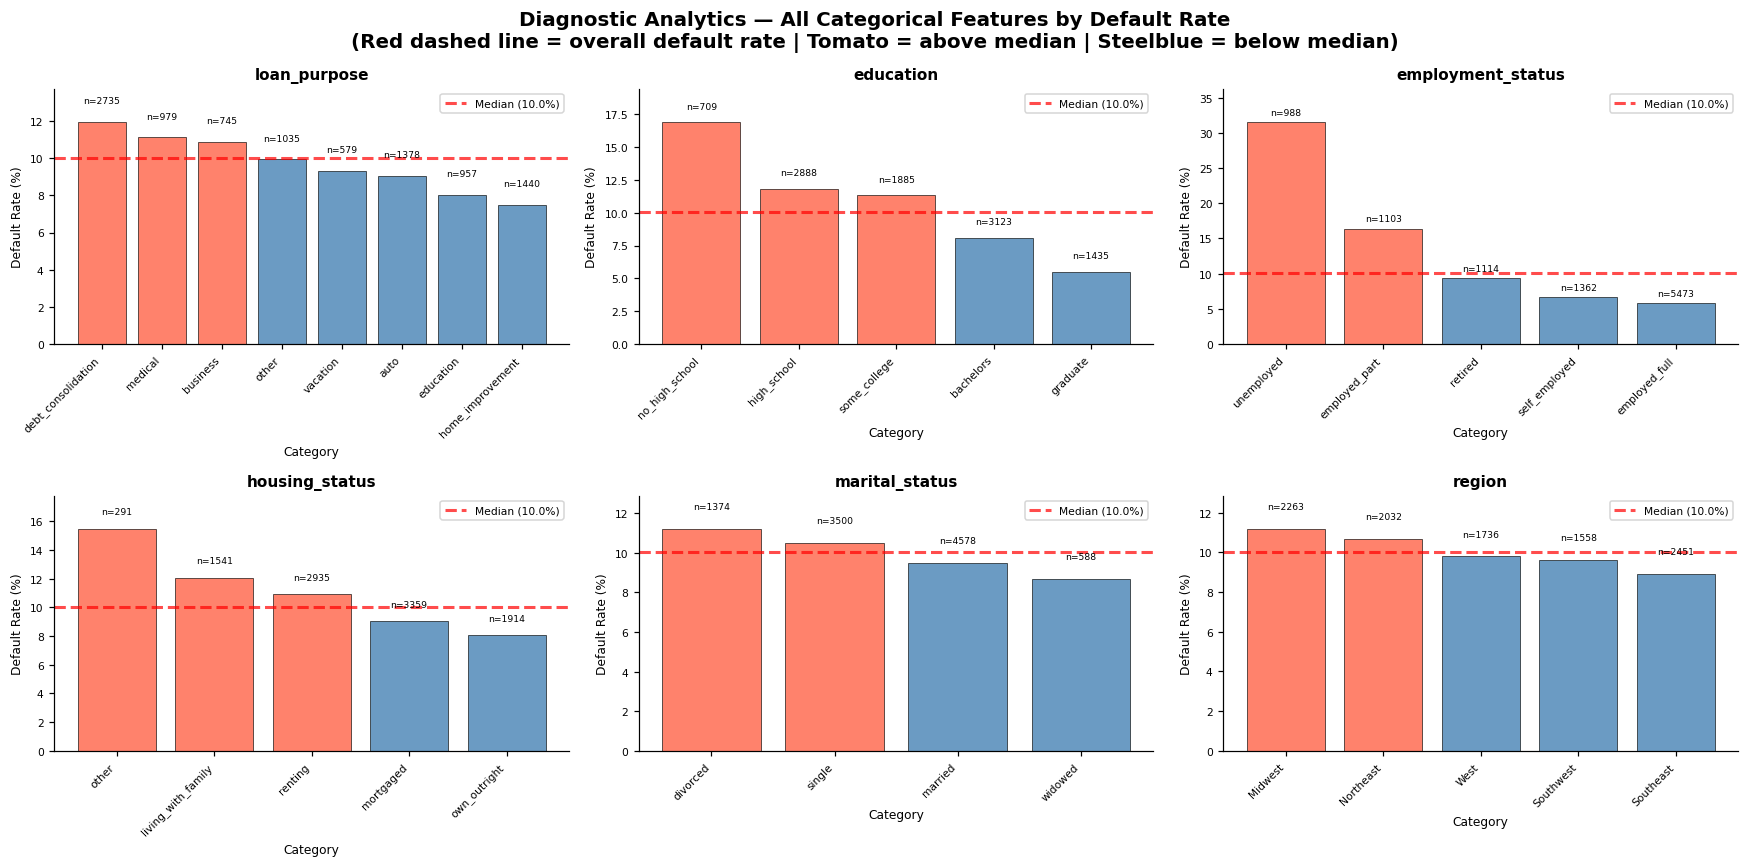


CATEGORICAL FEATURE ANALYSIS GUIDE:
STRONG PREDICTORS: Bars far above or below the red median line
WEAK PREDICTORS: All bars close to the red median line (no clear difference)


In [6]:
# ── 3.3b Diagnostic — Categorical Features by Default Status ──────────────

# Get all categorical columns (excluding IDs, dates, and redundant date_of_birth since we have age)
exclude_cols = {'loan_id', 'customer_id', 'app_date', 'application_date', 'default_flag', 'default', 'date_of_birth'}
categorical_cols = [col for col in df_analysis.select_dtypes(include=['object']).columns 
                    if col not in exclude_cols]

print(f"Found {len(categorical_cols)} categorical features to analyze:")
print(categorical_cols)

# Calculate overall default rate (for reference line)
overall_default_rate = df_analysis['default_flag'].mean()
print(f"\nOverall default rate: {overall_default_rate:.1%}")

# Create subplots for categorical features
n_cols = 3
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

# Plot each categorical feature
for ax, col in zip(axes, categorical_cols):
    # Calculate default rate per category
    default_rate_by_cat = df_analysis.groupby(col)['default_flag'].agg(['sum', 'count'])
    default_rate_by_cat['rate'] = default_rate_by_cat['sum'] / default_rate_by_cat['count']
    default_rate_by_cat = default_rate_by_cat.sort_values('rate', ascending=False)
    
    if len(default_rate_by_cat) == 0:
        ax.text(0.5, 0.5, f'No data for {col}', ha='center', va='center', fontsize=10)
        ax.set_title(col, fontweight='bold')
        continue
    
    try:
        # Plot default rate (%) as bars
        x = np.arange(len(default_rate_by_cat))
        colors = ['tomato' if rate > overall_default_rate else 'steelblue' 
                 for rate in default_rate_by_cat['rate']]
        ax.bar(x, default_rate_by_cat['rate'] * 100, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
        
        # Add horizontal line for overall default rate
        ax.axhline(y=overall_default_rate * 100, color='red', linestyle='--', linewidth=2, 
                   label=f'Median ({overall_default_rate:.1%})', alpha=0.7)
        
        ax.set_title(f'{col}', fontweight='bold', fontsize=10)
        ax.set_xlabel('Category', fontsize=8)
        ax.set_ylabel('Default Rate (%)', fontsize=8)
        ax.set_xticks(x)
        ax.set_xticklabels(default_rate_by_cat.index, rotation=45, ha='right', fontsize=7)
        ax.set_ylim(0, max(default_rate_by_cat['rate'] * 100) * 1.15)
        ax.legend(fontsize=7, loc='upper right')
        ax.tick_params(labelsize=7)
        
        # Add count labels on bars
        for i, (idx, row) in enumerate(default_rate_by_cat.iterrows()):
            ax.text(i, row['rate'] * 100 + 1, f"n={int(row['count'])}", 
                   ha='center', fontsize=6, color='black')
    except Exception as e:
        ax.text(0.5, 0.5, f'Error plotting {col}:\n{str(e)[:30]}', 
                ha='center', va='center', fontsize=8)
        ax.set_title(col, fontweight='bold')

# Hide unused subplots
for ax in axes[len(categorical_cols):]:
    ax.set_visible(False)

plt.suptitle('Diagnostic Analytics — All Categorical Features by Default Rate\n(Red dashed line = overall default rate | Tomato = above median | Steelblue = below median)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("CATEGORICAL FEATURE ANALYSIS GUIDE:")
print("="*70)
print("STRONG PREDICTORS: Bars far above or below the red median line")
print("WEAK PREDICTORS: All bars close to the red median line (no clear difference)")
print("="*70)

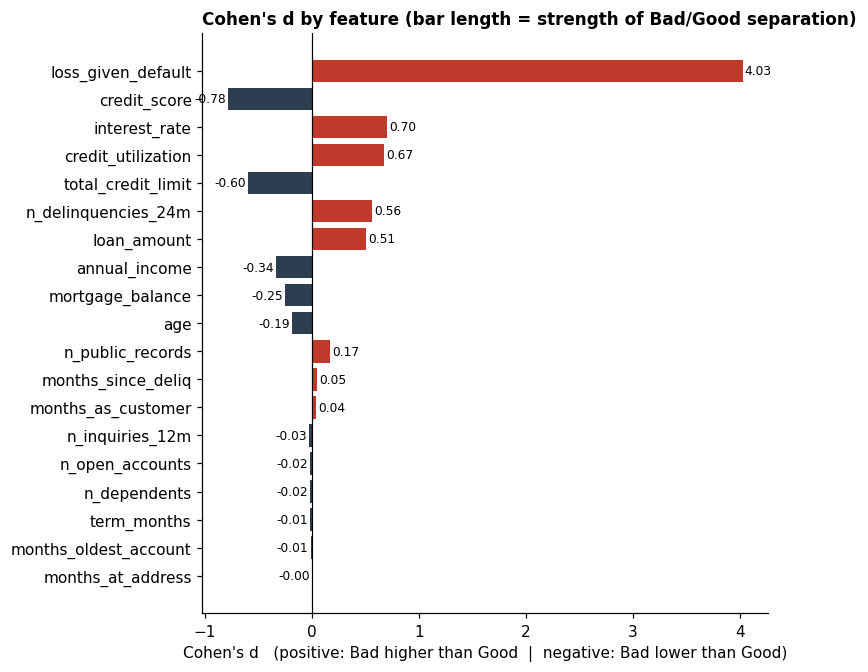

Top 5 numeric features by |Cohen's d| (strongest to weakest):
loss_given_default    4.028
credit_score         -0.783
interest_rate         0.703
credit_utilization    0.673
total_credit_limit   -0.600
dtype: float64


In [7]:
def cohens_d(good, bad):
    n1, n2 = len(good), len(bad)
    pooled_std = np.sqrt(((n1 - 1) * good.std()**2 + (n2 - 1) * bad.std()**2) / (n1 + n2 - 2))
    return (bad.mean() - good.mean()) / pooled_std if pooled_std > 0 else 0.0

effect_sizes = {}
for col in numeric_cols:
    good = df_analysis.loc[df_analysis['default_flag'] == 0, col].dropna()
    bad  = df_analysis.loc[df_analysis['default_flag'] == 1, col].dropna()
    if len(good) > 1 and len(bad) > 1:
        effect_sizes[col] = cohens_d(good, bad)

effect_sizes = pd.Series(effect_sizes)
effect_sorted = effect_sizes.reindex(effect_sizes.abs().sort_values().index)

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)

colors = ['#c0392b' if v > 0 else '#2c3e50' for v in effect_sorted.values]
bars = ax.barh(effect_sorted.index, effect_sorted.values, color=colors)
for b, v in zip(bars, effect_sorted.values):
    ax.text(v + (0.02 if v >= 0 else -0.02), b.get_y() + b.get_height()/2, f'{v:.2f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Cohen's d by feature (bar length = strength of Bad/Good separation)",
             fontweight='bold', loc='left', fontsize=11)
ax.set_xlabel("Cohen's d   (positive: Bad higher than Good  |  negative: Bad lower than Good)")
ax.spines[['top', 'right']].set_visible(False)


plt.show()

top5 = effect_sizes.reindex(effect_sizes.abs().sort_values(ascending=False).index).head(5)
print("Top 5 numeric features by |Cohen's d| (strongest to weakest):")
print(top5.round(3))


**Findings — ranked by |Cohen's d|:**

| Feature | Cohen's d |
|---|---|
| `credit_score` | −0.78 |
| `interest_rate` | +0.70 |
| `credit_utilization` | +0.67 |
| `total_credit_limit` | −0.60 |
| `n_delinquencies_24m` | +0.56 |

The three strongest **genuinely usable** predictors are:

1. **`credit_score`** (d = −0.78, the largest magnitude in the panel) — a bureau score summarising prior repayment behaviour, as expected to dominate in any production PD scorecard.
2. **`credit_utilization`** (d = +0.67) — bad borrowers run meaningfully higher utilization than good borrowers; high utilization signals current liquidity pressure, a leading indicator independent of `credit_score`.
3. **`n_delinquencies_24m`** (d = +0.56) — number of missed payments in the last 24 months; past repayment behaviour predicts future repayment behaviour.

**Important exception:** `interest_rate` shows the *second*-highest Cohen's d (+0.70) but is **not** included in the usable list above — see Section 3.5, where it turns out to be almost perfectly explained by `credit_score` (r = −0.91, VIF = 5.1) because FinVista's existing rules-based scorecard already prices risk into the rate at origination. Using it as a model input would mean re-using the old scorecard's own risk assessment rather than learning an independent signal.

`age`, `n_dependents`, and `months_at_address` show |d| < 0.1 — essentially no separation between good and bad borrowers, consistent with demographic attributes carrying far less signal than direct credit-behaviour features.

### 3.4 Riskiest Customer Segments

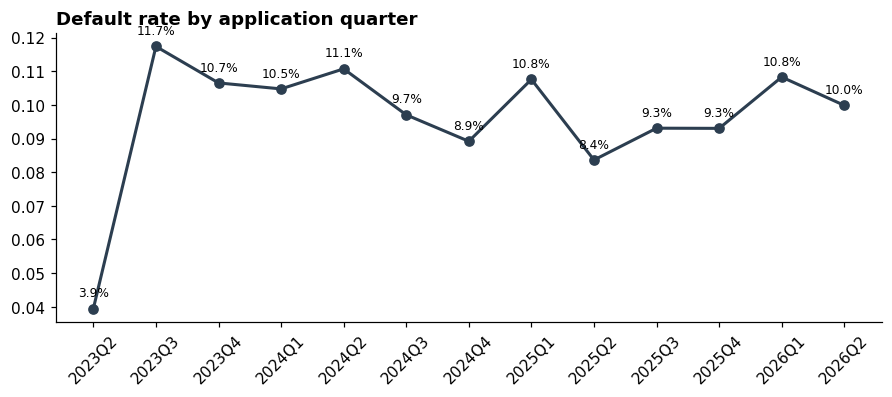

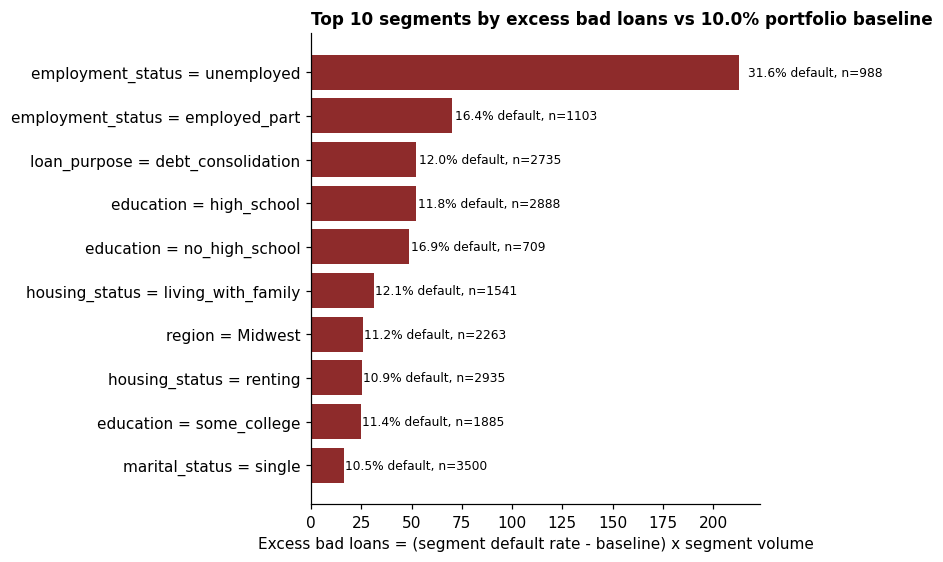

Portfolio baseline default rate: 10.0%

          feature           category  default_rate  n_loans  excess_bad_loans
employment_status         unemployed         0.316      988           212.806
employment_status      employed_part         0.164     1103            70.261
     loan_purpose debt_consolidation         0.120     2735            52.410
        education        high_school         0.118     2888            52.049
        education     no_high_school         0.169      709            48.818
   housing_status living_with_family         0.121     1541            31.286
           region            Midwest         0.112     2263            25.798
   housing_status            renting         0.109     2935            25.331
        education       some_college         0.114     1885            24.749
   marital_status             single         0.105     3500            16.606


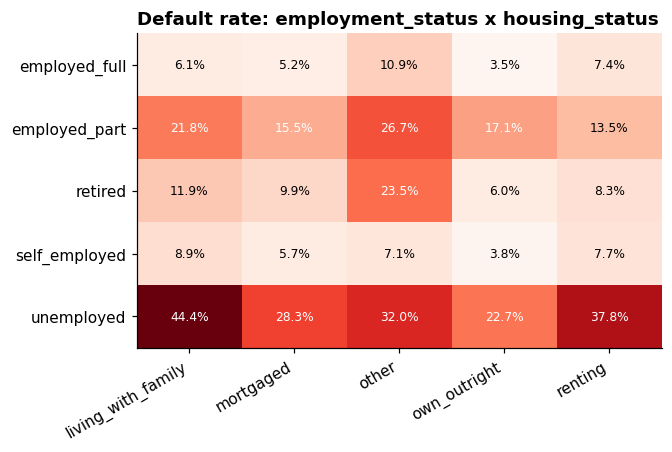


Top 2-way combinations by excess bad loans:
                                      n_loans  default_rate  excess_bad_loans
employment_status housing_status                                             
unemployed        renting                 254         0.378            70.499
                  mortgaged               314         0.283            57.475
                  living_with_family      135         0.444            46.446
                  own_outright            260         0.227            32.896
employed_part     mortgaged               349         0.155            18.961


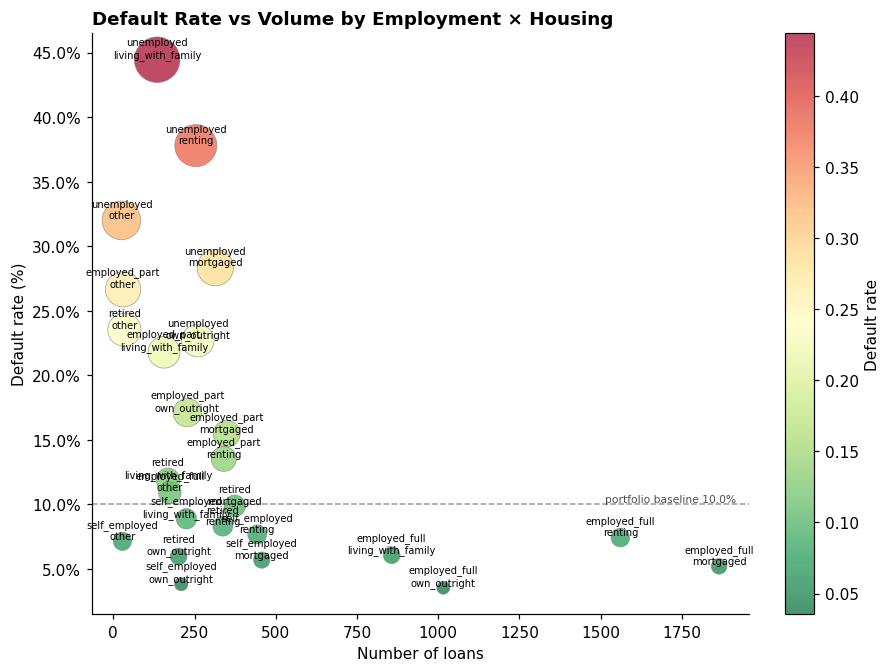

In [8]:
# --- 3.4 Riskiest customer groups: excess bad loans vs portfolio baseline ---
# NOTE: ranking segments by (default_rate x volume) alone is misleading -- it just
# rewards large segments regardless of whether they are actually riskier than average.
# The correct metric is EXCESS bad loans relative to the portfolio baseline default rate:
#   excess_bad_loans = (segment_default_rate - baseline_default_rate) x segment_volume
# This isolates segments that are both large AND riskier than the book as a whole.

baseline = df_analysis['default_flag'].mean()
categorical_cols = ['loan_purpose', 'education', 'employment_status',
                     'housing_status', 'marital_status', 'region']

rows = []
for col in categorical_cols:
    g = df_analysis.groupby(col)['default_flag'].agg(n_loans='count', default_rate='mean')
    g['excess_bad_loans'] = (g['default_rate'] - baseline) * g['n_loans']
    g['feature'] = col
    rows.append(g.reset_index().rename(columns={col: 'category'}))

seg_df = pd.concat(rows, ignore_index=True).sort_values('excess_bad_loans', ascending=False)

# Default-rate trend over time (by application quarter)
df_analysis['app_quarter'] = pd.to_datetime(df_analysis['application_date']).dt.to_period('Q').astype(str)
trend = df_analysis.groupby('app_quarter')['default_flag'].mean()

# Chart 1
fig, ax = plt.subplots(figsize=(8, 3.5), constrained_layout=True)
ax.plot(trend.index, trend.values, marker='o', color='#2c3e50', linewidth=2)
for x, y in zip(trend.index, trend.values):
    ax.annotate(f'{y:.1%}', (x, y), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=8)
ax.set_title('Default rate by application quarter', fontweight='bold', loc='left')
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=45)
plt.show()

# Chart 2
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
top10 = seg_df.head(10).iloc[::-1]
labels = top10['feature'] + ' = ' + top10['category'].astype(str)
bars = ax.barh(labels, top10['excess_bad_loans'], color='#8e2b2b')
for b, (rate, n) in zip(bars, zip(top10['default_rate'], top10['n_loans'])):
    ax.text(b.get_width() * 1.02, b.get_y() + b.get_height()/2,
            f'{rate:.1%} default, n={int(n)}', va='center', fontsize=8)
ax.set_title(f'Top 10 segments by excess bad loans vs {baseline:.1%} portfolio baseline',
             fontweight='bold', loc='left', fontsize=11)
ax.set_xlabel('Excess bad loans = (segment default rate - baseline) x segment volume')
ax.spines[['top', 'right']].set_visible(False)
plt.show()

print(f"Portfolio baseline default rate: {baseline:.1%}\n")
print(seg_df.head(10)[['feature', 'category', 'default_rate', 'n_loans', 'excess_bad_loans']]
      .round(3).to_string(index=False))

# Two-way combination: employment_status x housing_status
pivot = df_analysis.pivot_table(index='employment_status', columns='housing_status',
                                  values='default_flag', aggfunc='mean')
                                  
# Chart 3
fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
im = ax.imshow(pivot.values, cmap='Reds', aspect='auto')
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=30, ha='right')
ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1%}', ha='center', va='center',
                    color='white' if val > np.nanmean(pivot.values) else 'black', fontsize=8)
ax.set_title('Default rate: employment_status x housing_status', fontweight='bold', loc='left')
plt.show()

combo = df_analysis.groupby(['employment_status', 'housing_status'])['default_flag']\
    .agg(n_loans='count', default_rate='mean')
combo['excess_bad_loans'] = (combo['default_rate'] - baseline) * combo['n_loans']
print("\nTop 2-way combinations by excess bad loans:")
print(combo.sort_values('excess_bad_loans', ascending=False).head(5).round(3))

# Chart 4
combo_plot = combo.reset_index()  

fig, axes = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)
ax = axes if not hasattr(axes, '__len__') else axes[0]

scatter = ax.scatter(
    combo_plot['n_loans'], combo_plot['default_rate'] * 100,
    s=combo_plot['default_rate'] * 2000, alpha=0.7,
    c=combo_plot['default_rate'], cmap='RdYlGn_r', edgecolors='grey', linewidths=0.5
)
for _, row in combo_plot.iterrows():
    ax.annotate(f"{row['employment_status']}\n{row['housing_status']}",
                (row['n_loans'], row['default_rate'] * 100),
                fontsize=6.5, ha='center', va='bottom')

ax.set_xlabel('Number of loans')
ax.set_ylabel('Default rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Default Rate vs Volume by Employment × Housing', fontweight='bold', loc='left')
ax.axhline(baseline * 100, color='black', linestyle='--', alpha=0.4, linewidth=1)
ax.annotate(f'portfolio baseline {baseline:.1%}', (ax.get_xlim()[1]*0.98, baseline*100),
            ha='right', va='bottom', fontsize=7, alpha=0.7)
plt.colorbar(scatter, ax=ax, label='Default rate')
plt.show()


**Findings.** Ranking every category by **excess bad loans** = (segment default rate − 10.0% portfolio baseline) × segment volume, the two most important segments are:

1. **`employment_status = unemployed`** — by far the single largest contributor (excess ≈ 213 bad loans above what the baseline rate would predict). Default rate is 31.6% (3× the 10.0% portfolio baseline) across 988 loans (~9.8% of the book) — both far riskier than average *and* large enough in volume to matter. Unstable or absent income is the most direct driver of repayment failure.
2. **`employment_status = employed_part` (part-time employment)** — the second-largest contributor (excess ≈ 70 bad loans), default rate 16.4% across 1,103 loans. Part-time income is more volatile and more exposed to hours being cut than full-time employment.

The specific **two-way combination** with the highest excess risk is **unemployed × renting** (37.8% default, n=254, excess ≈ 70), followed by **unemployed × mortgaged** (28.3% default, n=314, excess ≈ 57), then **unemployed × living_with_family** (44.4% default — the single highest raw default rate of any segment — n=135, excess ≈ 46). Although `unemployed × living_with_family` has the worst default rate in the entire dataset, its lower volume means it generates fewer excess bad loans in absolute terms than the renting and mortgaged combinations, so the priority from a loss-exposure perspective remains **unemployed × renting** and **unemployed × mortgaged**.

### 3.5 Leakage & Multicollinearity Screening

Before any feature is carried into the modelling feature set, it has to clear three checks: (1) it cannot be a form of target leakage — information that would not actually be known at the moment of the approve/reject decision; (2) it cannot be redundant with a stronger feature already selected (multicollinearity); (3) its relationship with default must have a defensible business explanation, not just a high correlation number.

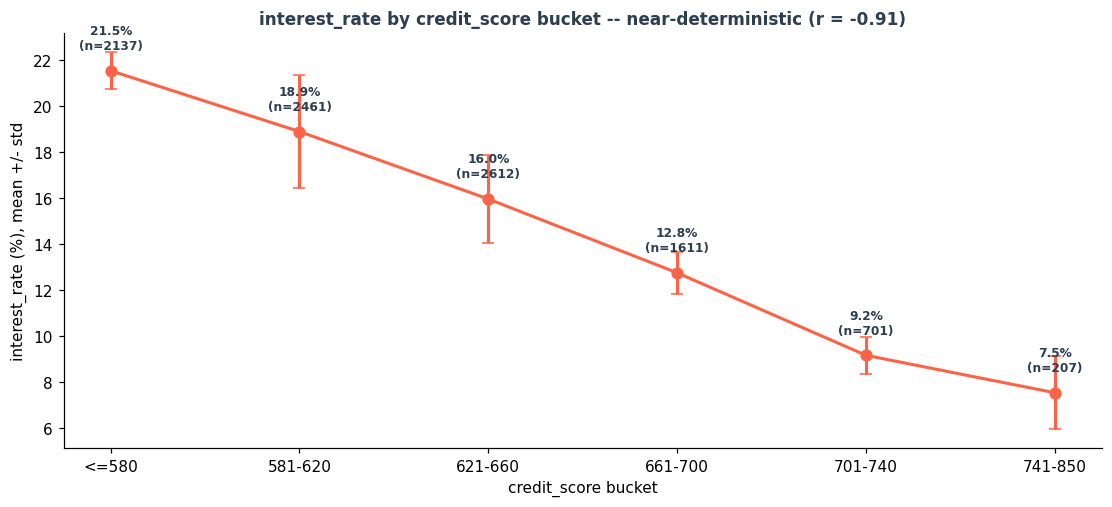

corr(interest_rate, credit_score) = -0.909


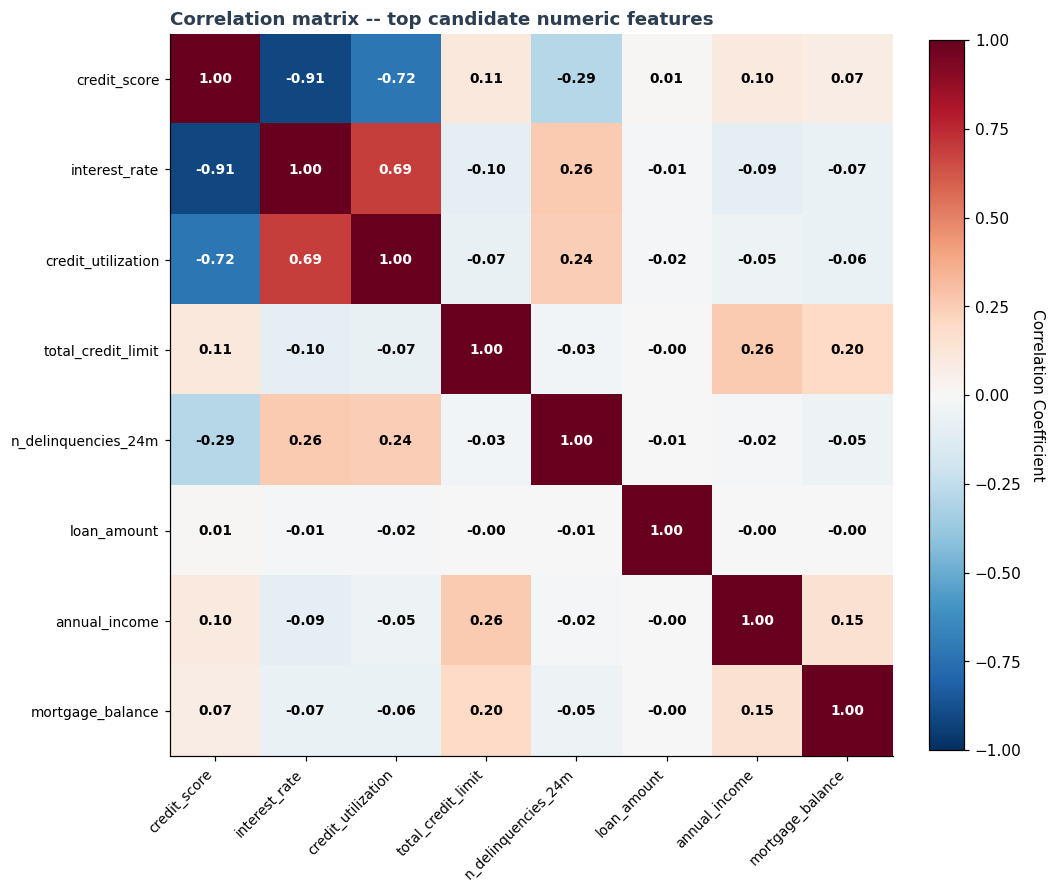


VARIANCE INFLATION FACTOR (VIF) DIAGNOSTICS:
            Feature  VIF
       credit_score 5.40
      interest_rate 5.13
 credit_utilization 2.09
 total_credit_limit 1.11
n_delinquencies_24m 1.09
      annual_income 1.09
   mortgage_balance 1.06
        loan_amount 1.00
--------------------------------------------------
VIF > 5.0 indicates problematic multicollinearity.
VIF > 10.0 indicates severe redundancy (must remove).

Transaction data starts: 2024-12-20
Loans applied BEFORE transaction history: 5037 / 10040 loans (50.2%)


In [9]:
# --- 3.5 Leakage & multicollinearity diagnostics ---

# (a) Hard leakage: loss_given_default is only observed AFTER a default occurs
#     (business_brief.md and data_dictionary.md are both explicit about this) -> excluded
#     from every feature set below, already excluded from numeric_cols/exclude_cols throughout.

# (b) interest_rate: data_dictionary.md itself flags this as "partly endogenous ... set by
#     our own (imperfect) underwriting rules". Confirm and quantify that with the real data.
merged = df_analysis.copy()
merged['score_bucket'] = pd.cut(merged['credit_score'], bins=[0, 580, 620, 660, 700, 740, 850],
                                  labels=['<=580', '581-620', '621-660', '661-700', '701-740', '741-850'])
bucket_stats = merged.groupby('score_bucket', observed=True)['interest_rate'].agg(['mean', 'std', 'count'])

# Chart 1
fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
ax.errorbar(range(len(bucket_stats)), bucket_stats['mean']*100, yerr=bucket_stats['std']*100,
            fmt='o-', color='tomato', capsize=4, linewidth=2, markersize=7)
ax.set_xticks(range(len(bucket_stats))); ax.set_xticklabels(bucket_stats.index)

for i, (m, s, n) in enumerate(zip(bucket_stats['mean'], bucket_stats['std'], bucket_stats['count'])):
    ax.annotate(f'{m*100:.1f}%\n(n={n})', (i, m*100), textcoords='offset points', xytext=(0, 14),
                ha='center', fontsize=8, fontweight='bold', color='#2c3e50')
                
ax.set_title('interest_rate by credit_score bucket -- near-deterministic (r = -0.91)',
             fontweight='bold', loc='center', fontsize=11, color='#2c3e50')
ax.set_ylabel('interest_rate (%), mean +/- std')
ax.set_xlabel('credit_score bucket')
ax.spines[['top', 'right']].set_visible(False)
plt.show()

print(f"corr(interest_rate, credit_score) = {merged[['interest_rate','credit_score']].corr().iloc[0,1]:.3f}")


# (c) Correlation / multicollinearity among the strongest candidate numeric features
corr_cols = ['credit_score', 'interest_rate', 'credit_utilization', 'total_credit_limit',
             'n_delinquencies_24m', 'loan_amount', 'annual_income', 'mortgage_balance']
corr = df_analysis[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9.5, 8.5), constrained_layout=True)
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)

cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label('Correlation Coefficient', rotation=270, labelpad=15)

ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols, fontsize=9)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                color='white' if abs(val) > 0.55 else 'black', fontsize=9, fontweight='bold')
                
ax.set_title('Correlation matrix -- top candidate numeric features', fontweight='bold', loc='left', fontsize=12, color='#2c3e50')
plt.show()


# (d) Variance Inflation Factor (VIF)
X = df_analysis[corr_cols].fillna(df_analysis[corr_cols].median())
vif_values = np.diag(np.linalg.inv(X.corr().values))
vif_df = pd.DataFrame({
    'Feature': corr_cols,
    'VIF': vif_values
}).sort_values('VIF', ascending=False)

print("\n" + "="*50)
print("VARIANCE INFLATION FACTOR (VIF) DIAGNOSTICS:")
print("="*50)
print(vif_df.round(2).to_string(index=False))
print("-"*50)
print("VIF > 5.0 indicates problematic multicollinearity.")
print("VIF > 10.0 indicates severe redundancy (must remove).")
print("="*50)


# (e) Transaction feature coverage
txn_start = pd.to_datetime(transactions['txn_date']).min()
loans_app_date = pd.to_datetime(loans['application_date'])
n_before = (loans_app_date < txn_start).sum()

print(f"\nTransaction data starts: {txn_start.date()}")
print(f"Loans applied BEFORE transaction history: {n_before} / {len(loans)} loans ({n_before/len(loans):.1%})")


**Findings and decisions:**

| Feature | Issue found | Decision |
|---|---|---|
| `loss_given_default` | Hard leakage — only known *after* a default occurs. | **Exclude** from all model inputs. Keep only for the business-impact scoring in Section 8. |
| `interest_rate` | Partly endogenous — set by FinVista's own existing scorecard. Confirmed on the real data: r = −0.909 with `credit_score`, VIF = 5.1 (> 5 threshold). Mean rate falls in a near-deterministic step from 21.5% (score ≤580) to 7.6% (score 741–850), with very small within-bucket std at every step. | **Exclude** as a PD model input. It reproduces the old scorecard's own risk assessment rather than adding independent signal. |
| `age`, `months_as_customer`, `months_oldest_account` | These are measured at the snapshot date (2026-06-20), but `loans.application_date` spans nearly 3 years earlier for the oldest vintage. Since the customer and credit tables are static one-row-per-customer snapshots with no historical version, these fields reflect the customer's status **today**, not at the time of the specific loan application — a real point-in-time leakage risk that grows for older-vintage loans. | **Flag as a known data limitation.** Cannot be fully corrected with the tables available. Mitigated by monitoring model performance by application-quarter vintage (Section 6/7) and treating features built from these fields with caution rather than as a primary driver. |
| `credit_utilization` | Correlated with `credit_score` (r ≈ −0.72) but VIF only 2.1 — well under the problematic threshold once `interest_rate` is removed. | **Keep.** Captures current liquidity pressure, a distinct concept from the bureau score's longer-history view. |
| Transaction-derived features | 50.2% of loans were applied for *before* the transaction table's earliest date (2024-12-20) — no pre-application transaction history exists for roughly half the portfolio. | **Keep, with an explicit `no_txn_history` flag** (built into the point-in-time join in Section 4) so the model can learn that "no history" is a distinct, informative state. |
| `annual_income`, `mortgage_balance` | Low VIF (≈1.1), moderate Cohen's d. | **Keep.** Independent signal, no redundancy concern. |

**Feature set carried forward:** `credit_score`, `credit_utilization`, `total_credit_limit`, `n_delinquencies_24m`, `annual_income`, `mortgage_balance`, `loan_amount`, `term_months`, all categorical features from 3.4, plus the point-in-time transaction aggregates (with `no_txn_history` flag) from Section 4. `interest_rate` and `loss_given_default` are excluded from the model input set; `age`/`months_as_customer`/`months_oldest_account` are carried forward provisionally with the vintage-monitoring caveat noted above.

## 4. Data Cleaning & Feature Joining

In [10]:
# ============================================================
# SECTION 4 -- Cleaning & Joining the Data
# ============================================================

# ---------- 4.1 Remove duplicate loan applications ----------
dup_keys = ['customer_id', 'application_date', 'loan_amount']
n_before = len(loans)

dup_mask = loans.duplicated(subset=dup_keys, keep=False)
conflict = loans[dup_mask].groupby(dup_keys)['default_flag'].nunique().gt(1)
if conflict.any():
    print(f"WARNING: {conflict.sum()} duplicate groups have conflicting default_flag values.")

loans_clean = loans.drop_duplicates(subset=dup_keys, keep='first').reset_index(drop=True)
n_after = len(loans_clean)
print(f"Loans: {n_before} -> {n_after} rows "
      f"(removed {n_before - n_after} duplicate applications, matches the ~40 the dictionary flagged; "
      f"{int(conflict.sum())} had conflicting default_flag)")

# ---------- 4.2a annual_income missing values ----------
# The dictionary claims MAR (missing at random w.r.t. income level) and recommends imputing
# with the median segmented by employment_status. Verify both claims on the real data first.
customers_clean = customers.copy()
miss_rate_by_emp = customers_clean.groupby('employment_status')['annual_income'].apply(lambda s: s.isna().mean())
med_by_emp = customers_clean.groupby('employment_status')['annual_income'].median()
print("\nMissingness rate by employment_status (should be roughly flat if truly MAR):")
print(miss_rate_by_emp.round(3))
print("\nMedian income by employment_status (justifies segmented imputation if these differ a lot):")
print(med_by_emp.round(0))

customers_clean['income_was_missing'] = customers_clean['annual_income'].isna().astype(int)
customers_clean['annual_income'] = customers_clean.groupby('employment_status')['annual_income']\
    .transform(lambda s: s.fillna(s.median()))

# ---------- 4.2b annual_income outliers ----------
# Dictionary: "values above ~£350,000 should be treated as outliers -- cap at the 99th percentile"
cap_val = customers_clean['annual_income'].quantile(0.99)
n_capped = (customers_clean['annual_income'] > cap_val).sum()
n_extreme = (customers_clean['annual_income'] > 600_000).sum()
customers_clean['income_was_capped'] = (customers_clean['annual_income'] > cap_val).astype(int)
customers_clean['annual_income'] = customers_clean['annual_income'].clip(upper=cap_val)
print(f"\nannual_income: capped at the 99th percentile (£{cap_val:,.0f}) per data_dictionary.md -- "
      f"{n_capped} customers capped, of which {n_extreme} exceeded the documented plausible max of "
      f"£600,000 (up to £2.83M -- almost certainly data-entry errors, not just natural high earners)")

# ---------- 4.3 Aggregate transactions -> loan-level, POINT-IN-TIME (no target leakage) ----------
txn = transactions.copy()
txn['txn_date'] = pd.to_datetime(txn['txn_date'])
loans_clean['application_date'] = pd.to_datetime(loans_clean['application_date'])
txn = txn.sort_values(['customer_id', 'txn_date'])

txn['cum_n_txn'] = txn.groupby('customer_id').cumcount() + 1
txn['cum_total_amount'] = txn.groupby('customer_id')['txn_amount'].cumsum()
txn['cum_cash_stress'] = txn.groupby('customer_id')['cash_stress_flag'].cumsum()

def rolling_window_sum(g, days):
    g = g.set_index('txn_date')
    return g['txn_amount'].rolling(f'{days}D').sum().values

txn['roll_90d_amount'] = txn.groupby('customer_id', group_keys=False).apply(
    lambda g: pd.Series(rolling_window_sum(g, 90), index=g.index)
)

loans_sorted = loans_clean.sort_values('application_date')
txn_sorted = txn.sort_values('txn_date')

# direction='backward' guarantees only transactions strictly before application_date are used
master_txn = pd.merge_asof(
    loans_sorted,
    txn_sorted[['customer_id', 'txn_date', 'cum_n_txn', 'cum_total_amount',
                'cum_cash_stress', 'roll_90d_amount']],
    left_on='application_date', right_on='txn_date',
    by='customer_id', direction='backward'
)

master_txn['recency_days']    = (master_txn['application_date'] - master_txn['txn_date']).dt.days
master_txn['n_transactions']  = master_txn['cum_n_txn'].fillna(0)
master_txn['total_spend']     = master_txn['cum_total_amount'].fillna(0)
master_txn['n_cash_advances'] = master_txn['cum_cash_stress'].fillna(0)
master_txn['spend_last_90d']  = master_txn['roll_90d_amount'].fillna(0)
master_txn['no_txn_history']  = master_txn['txn_date'].isna().astype(int)
master_txn['recency_days']    = master_txn['recency_days'].fillna(-1)  # sentinel: no prior transaction exists

master_txn = master_txn.drop(columns=['txn_date', 'cum_n_txn', 'cum_total_amount',
                                       'cum_cash_stress', 'roll_90d_amount'])

print(f"\n{int(master_txn['no_txn_history'].sum())}/{len(master_txn)} loan applications "
      f"({master_txn['no_txn_history'].mean():.1%}) have no transaction history before application_date "
      f"-- consistent with the transaction table only starting 2024-12-20 (see Section 3.5). "
      f"recency_days is set to sentinel -1 for these; no_txn_history flags them explicitly.")

# ---------- 4.4 Join all four tables ----------
master = (
    master_txn
    .merge(customers_clean, on='customer_id', how='left')
    .merge(credit_history, on='customer_id', how='left')
)

# ---------- 4.5 Remaining missing values, column by column ----------

# credit_score: dictionary attributes missingness to "thin-file" customers. Test that claim
# empirically before choosing an imputation strategy.
miss = master['credit_score'].isna()
oa_miss = master.loc[miss, 'n_open_accounts'].median()
oa_present = master.loc[~miss, 'n_open_accounts'].median()
print(f"\nThin-file check: median n_open_accounts = {oa_miss:.0f} (missing-score) vs "
      f"{oa_present:.0f} (present-score) -- not meaningfully different in this data, "
      f"so the documented thin-file rationale is NOT supported here.")

master['credit_score_was_missing'] = master['credit_score'].isna().astype(int)
overall_median_score = master['credit_score'].median()
master['credit_score'] = master['credit_score'].fillna(overall_median_score)
print(f"credit_score: imputed with the overall median ({overall_median_score:.0f}) + missing flag "
      f"(a thin-file-segmented median is not justified by the evidence above)")

# months_since_deliq: MNAR by design (NaN = never delinquent). Sentinel + flag, NOT median imputation.
master['ever_delinquent'] = master['months_since_deliq'].notna().astype(int)
master['months_since_deliq'] = master['months_since_deliq'].fillna(999)
print(f"months_since_deliq: {int((~master['ever_delinquent'].astype(bool)).sum())} customers never "
      f"delinquent (structurally missing, MNAR) -> sentinel 999 + ever_delinquent flag")

# n_inquiries_12m: MAR (system migration window per dictionary) -> median + flag
master['inquiries_was_missing'] = master['n_inquiries_12m'].isna().astype(int)
inq_median = master['n_inquiries_12m'].median()
master['n_inquiries_12m'] = master['n_inquiries_12m'].fillna(inq_median)
print(f"n_inquiries_12m: median imputation ({inq_median:.0f}) + missing flag")

# months_at_address: MAR (form bug per dictionary) -> median + flag
master['address_tenure_was_missing'] = master['months_at_address'].isna().astype(int)
addr_median = master['months_at_address'].median()
master['months_at_address'] = master['months_at_address'].fillna(addr_median)
print(f"months_at_address: median imputation ({addr_median:.0f}) + missing flag")

# loan_purpose: categorical -> its own 'unknown' category, never mode (per dictionary)
master['loan_purpose'] = master['loan_purpose'].fillna('unknown')
print("loan_purpose: filled with 'unknown' category (not mode -- purpose carries genuine risk signal)")

# ---------- 4.6 Final diagnostics ----------
missing_pct = master.isna().mean().sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print(f"\nRemaining missing values after cleaning: {'none' if len(missing_pct) == 0 else missing_pct.to_dict()}")
print(f"Final shape of master: {master.shape}")
print(f"Default rate in master: {master['default_flag'].mean():.2%}")

Loans: 10040 -> 9999 rows (removed 41 duplicate applications, matches the ~40 the dictionary flagged; 0 had conflicting default_flag)

Missingness rate by employment_status (should be roughly flat if truly MAR):
employment_status
employed_full    0.041
employed_part    0.035
retired          0.058
self_employed    0.044
unemployed       0.030
Name: annual_income, dtype: float64

Median income by employment_status (justifies segmented imputation if these differ a lot):
employment_status
employed_full    71600.0
employed_part    30700.0
retired          41200.0
self_employed    80200.0
unemployed       19200.0
Name: annual_income, dtype: float64

annual_income: capped at the 99th percentile (£191,601) per data_dictionary.md -- 80 customers capped, of which 15 exceeded the documented plausible max of £600,000 (up to £2.83M -- almost certainly data-entry errors, not just natural high earners)

5291/9999 loan applications (52.9%) have no transaction history before application_date -- consis

**Duplicates:** 41 duplicate applications removed (same `customer_id` + `application_date` + `loan_amount`), matching the ~40 suspected duplicates flagged in the data dictionary. None had conflicting `default_flag` values, so simple first-row dedup was safe.

**`annual_income` — two separate issues, two separate fixes:**
- *Missing (4.2%):* verified the missing-at-random claim first — missingness rate is roughly flat across `employment_status` (3.0%–5.8%), consistent with MAR. But segment medians differ sharply (£19,200 unemployed vs £80,200 self-employed), so imputing with the *overall* median would be wrong for this population. Imputed with the median **segmented by `employment_status`**, plus an `income_was_missing` flag.
- *Outliers:* capped at the 99th percentile (£191,601). This affected 80 customers; 15 of those exceeded the documented plausible maximum of £600,000 (up to £2.83M) and are almost certainly data-entry errors rather than genuine high earners.

**`credit_score` (3.2% missing) — the documented "thin-file" explanation was tested and found unsupported:** the dictionary attributes missingness to thin-file customers and recommends a thin-file-segmented median. Checked directly: median `n_open_accounts` is identical (9) for missing-score and present-score records — the thin-file signal is not present in this data. Rather than force a segmentation the evidence doesn't support, imputed with the **overall median (625)** plus a `credit_score_was_missing` flag, letting the flag itself carry whatever signal the missingness has.

**`months_since_deliq` — structurally missing, not ordinary missing data:** `NaN` means "never delinquent" (7,752 customers), not a data gap. A median would incorrectly treat "never delinquent" as "moderately overdue." Filled with a large sentinel (999) plus an `ever_delinquent` flag instead.

**`n_inquiries_12m` (4.9% missing) and `months_at_address` (5.3% missing):** both missing-at-random (system migration window; form bug respectively) — median imputation (1 and 25 months respectively) plus a missing-value flag for each, so the model can still learn if missingness itself carries residual signal.

**`loan_purpose` (1.9% missing):** filled with a distinct `'unknown'` category rather than the mode, since purpose carries genuine risk signal that a mode-imputed value would erase.

**Transaction features (all computed point-in-time, using only transactions strictly before each loan's `application_date`):**
- `n_transactions`, `total_spend` — overall account activity level up to the application date.
- `n_cash_advances` — count of cash-advance transactions over £500, the strongest liquidity-stress signal in the transaction data.
- `spend_last_90d` — recent spending intensity, a short-window complement to the full-history totals.
- `recency_days` — days since the last transaction before application (sentinel −1 where none exists).
- `no_txn_history` — 52.9% of applications (5,291/9,999) have no transaction record before their `application_date`, since the transaction table only starts 2024-12-20 while loans go back to 2023-06-21. This flag lets the model treat "no history" as a distinct state rather than silently coding it as zero spend.

**Final shape of `master`: (9,999, 42)** — no missing values remain. Default rate: 10.03%, consistent with the 10.0% observed in the raw `loans` table.

In [11]:
master.head(5)

,loan_id,customer_id,application_date,loan_amount,loan_purpose,term_months,interest_rate,default_flag,loss_given_default,recency_days,...,months_oldest_account,n_delinquencies_24m,n_public_records,n_inquiries_12m,months_since_deliq,mortgage_balance,credit_score_was_missing,ever_delinquent,inquiries_was_missing,address_tenure_was_missing
0,L0005733,C007071,2023-06-21,5000,business,36,0.2059,0,0.0,-1.0,...,139,1,0,1.0,8.0,0,0,1,0,0
1,L0005189,C004725,2023-06-21,30000,business,12,0.1000,0,0.0,-1.0,...,12,0,0,1.0,999.0,397000,0,0,0,0
2,L0007882,C000180,2023-06-21,50000,other,60,0.1295,0,0.0,-1.0,...,18,0,1,4.0,999.0,135000,0,0,0,0
3,L0008883,C002395,2023-06-21,5000,vacation,36,0.1607,0,0.0,-1.0,...,62,0,0,1.0,999.0,120000,0,0,0,0
4,L0003844,C002138,2023-06-22,20000,vacation,48,0.1713,0,0.0,-1.0,...,117,0,0,0.0,999.0,302000,0,0,0,0


## Column Reference: `master`

`master` is built by joining all four source tables, with additional engineered columns added during cleaning and transaction aggregation.

---

### Identifiers & Target

| Column | Type | Description |
|--------|------|-------------|
| `customer_id` | str | Unique customer identifier (join key) |
| `application_date` | datetime | Date the loan application was submitted |
| `default_flag` | int (0/1) | **Target variable** — 1 = defaulted, 0 = repaid |

---

### Loan Information (from `loans`)

| Column | Type | Description |
|--------|------|-------------|
| `loan_amount` | float | Loan amount requested (£) |
| `loan_purpose` | str | Purpose: `car`, `home_improvement`, `debt_consolidation`, `education`, `medical`, `vacation`, `other`, `unknown` |
| `term_months` | int | Loan term in months |
| `interest_rate` | float | Interest rate — ⚠️ *excluded from model features* (partly endogenous — set by the bank's own underwriting rules) |

---

### Customer Demographics (from `customers`)

| Column | Type | Description |
|--------|------|-------------|
| `education` | str | Highest qualification: `no_high_school`, `high_school`, `some_college`, `bachelors`, `graduate` |
| `employment_status` | str | Employment: `employed_full`, `employed_part`, `self_employed`, `unemployed`, `retired` |
| `annual_income` | float | Gross annual income (£) — imputed by employment-status median, capped at 99th percentile |
| `housing_status` | str | Housing: `own_outright`, `mortgaged`, `renting`, `living_with_family`, `other` |
| `months_at_address` | float | Months at current address — imputed with median |
| `marital_status` | str | Marital status: `single`, `married`, `divorced`, `widowed` |
| `n_dependents` | int | Number of financial dependants (0–4) |
| `region` | str | Geographic region: `Northeast`, `Southeast`, `Midwest`, `Southwest`, `West` |
| `months_as_customer` | int | Months since the customer first joined the bank |
| `age` | int | Customer age at application |

---

### Credit History (from `credit_history`)

| Column | Type | Description |
|--------|------|-------------|
| `credit_score` | float | Credit score — imputed with overall median where missing |
| `credit_utilization` | float | Proportion of total credit limit currently used (0–1) |
| `total_credit_limit` | float | Sum of all credit limits across accounts (£) |
| `n_delinquencies_24m` | int | Number of late payments in the past 24 months |
| `mortgage_balance` | float | Outstanding mortgage balance (£); 0 if no mortgage |
| `n_open_accounts` | int | Number of open credit accounts |
| `months_oldest_account` | int | Age in months of the oldest credit account |
| `n_inquiries_12m` | float | Hard credit enquiries in the past 12 months — imputed with median |
| `months_since_deliq` | float | Months since last delinquency — structurally missing (MNAR) if never delinquent; replaced with sentinel `999` |

---

### Point-in-Time Transaction Aggregates (from `transactions`, cut off at `application_date`)

| Column | Type | Description |
|--------|------|-------------|
| `n_transactions` | float | Total number of transactions before application date |
| `total_spend` | float | Cumulative spend (£) before application date |
| `n_cash_advances` | float | Cumulative count of cash-advance / cash-stress transactions |
| `spend_last_90d` | float | Total spend in the 90 days before application date (£) |
| `recency_days` | float | Days between the most recent transaction and application date; `-1` sentinel if no history |
| `no_txn_history` | int | Flag — 1 if the customer has no transaction records before the application date |

---

### Engineering Flags (created during cleaning)

| Column | Type | Description |
|--------|------|-------------|
| `income_was_missing` | int | 1 if `annual_income` was originally missing |
| `income_was_capped` | int | 1 if `annual_income` was capped at the 99th percentile |
| `credit_score_was_missing` | int | 1 if `credit_score` was originally missing |
| `ever_delinquent` | int | 1 if the customer has any delinquency history |
| `inquiries_was_missing` | int | 1 if `n_inquiries_12m` was originally missing |
| `address_tenure_was_missing` | int | 1 if `months_at_address` was originally missing |

## 5. Feature Engineering

For categorical columns (employment type, loan purpose, and so on), Weight-of-Evidence (WoE) encoding replaces each category with a single number reflecting how risky that category is relative to the average, computed as the log-ratio of the fraction of defaulters to non-defaulters within the category:

$$\text{WoE for a category} = \ln\!\left(\frac{\text{fraction of defaulters in this category}}{\text{fraction of non-defaulters in this category}}\right)$$

Each encoded column's **Information Value (IV)** then summarises how useful it is for predicting default:

$$\text{IV for a column} = \sum_{\text{categories}} \bigl(\text{fraction of defaulters} - \text{fraction of non-defaulters}\bigr) \times \text{WoE}$$

| IV value | What it means |
|---|---|
| Below 0.02 | Not useful — consider leaving it out |
| 0.02 – 0.10 | Weakly predictive |
| 0.10 – 0.30 | Moderately predictive |
| Above 0.30 | Strongly predictive |

WoE encoding was applied to six categorical columns, and IV computed for every numeric and categorical candidate feature to guide selection.

In [12]:
# ── WoE/IV calculation ─────────────────────────────────────────────────────────
def compute_woe_iv(df, feature, target, n_bins=10, is_categorical=False):
    """Compute per-bin WoE and aggregate IV for one feature."""
    tmp = df[[feature, target]].dropna(subset=[feature]).copy()

    if is_categorical:
        tmp['bin'] = tmp[feature].astype(str)
    else:
        tmp['bin'] = pd.qcut(tmp[feature], q=n_bins, duplicates='drop').astype(str)

    total_good = (tmp[target] == 0).sum()
    total_bad  = (tmp[target] == 1).sum()

    grouped = (
        tmp.groupby('bin')[target]
        .agg(n_good=lambda x: (x == 0).sum(),
             n_bad =lambda x: (x == 1).sum())
        .reset_index()
    )
    grouped['p_good'] = grouped['n_good'] / total_good
    grouped['p_bad']  = grouped['n_bad']  / total_bad

    eps = 1e-6
    grouped['woe'] = np.log((grouped['p_good'] + eps) / (grouped['p_bad'] + eps))
    grouped['iv']  = (grouped['p_good'] - grouped['p_bad']) * grouped['woe']

    grouped['feature'] = feature
    return grouped, round(grouped['iv'].sum(), 4)


# ── Feature lists ──────────────────────────────────────────────────────────────
CATEGORICAL_FEATS = [
    'loan_purpose',       # from loans
    'employment_status',  # from customers
    'housing_status',     # from customers
    'education',          # from customers
    'marital_status',     # from customers
    'region',             # from customers
]

NUMERIC_FEATS = [
    'loan_amount',            # from loans
    'term_months',            # from loans
    'annual_income',          # from customers
    'months_at_address',      # from customers
    'n_dependents',           # from customers
    'months_as_customer',     # from customers
    'age',                    # from customers
    'credit_score',           # from credit_history
    'credit_utilization',     # from credit_history
    'total_credit_limit',     # from credit_history
    'n_delinquencies_24m',    # from credit_history
    'mortgage_balance',       # from credit_history
    'n_open_accounts',        # from credit_history
    'months_oldest_account',  # from credit_history
    'n_inquiries_12m',        # from credit_history
    'months_since_deliq',     # from credit_history (999 = never delinquent)
    'n_transactions',         # transaction aggregates
    'total_spend',            # transaction aggregates
    'n_cash_advances',        # transaction aggregates
    'spend_last_90d',         # transaction aggregates
    'recency_days',           # transaction aggregates (-1 = no history)
]

# ── Compute IV for all features ────────────────────────────────────────────────
iv_summary = {}
woe_tables = {}

for feat in CATEGORICAL_FEATS:
    woe_tbl, iv = compute_woe_iv(master, feat, 'default_flag', is_categorical=True)
    iv_summary[feat] = {'IV': iv, 'type': 'categorical'}
    woe_tables[feat] = woe_tbl

for feat in NUMERIC_FEATS:
    woe_tbl, iv = compute_woe_iv(master, feat, 'default_flag', n_bins=10)
    iv_summary[feat] = {'IV': iv, 'type': 'numeric'}
    woe_tables[feat] = woe_tbl

# ── Rank: type first (categorical → numeric), then IV descending ───────────────
iv_df = (
    pd.DataFrame.from_dict(iv_summary, orient='index')
    .sort_values(['type', 'IV'], ascending=[True, False])
    .assign(
        strength=lambda x: pd.cut(
            x['IV'],
            bins=[-1, 0.02, 0.10, 0.30, 0.50, 999],
            labels=['Useless', 'Weak', 'Medium', 'Strong', 'Suspicious']
        )
    )
    [['type', 'IV', 'strength']]
)

print("Information Value ranking (sorted by type, then IV):")
print(iv_df.to_string())

Information Value ranking (sorted by type, then IV):
                              type      IV    strength
employment_status      categorical  0.5539  Suspicious
education              categorical  0.1088      Medium
loan_purpose           categorical  0.0352        Weak
housing_status         categorical  0.0333        Weak
region                 categorical  0.0097     Useless
marital_status         categorical  0.0068     Useless
annual_income              numeric  0.7170  Suspicious
credit_score               numeric  0.7043  Suspicious
credit_utilization         numeric  0.4925      Strong
total_credit_limit         numeric  0.3890      Strong
loan_amount                numeric  0.2801      Medium
months_since_deliq         numeric  0.1601      Medium
n_delinquencies_24m        numeric  0.1337      Medium
total_spend                numeric  0.1176      Medium
spend_last_90d             numeric  0.1088      Medium
mortgage_balance           numeric  0.0926        Weak
age         

In [13]:
# ── Section 5: Feature Engineering ────────────────────────────────────────────
# All features are computed strictly from columns available at application time
# (no target leakage). interest_rate and loss_given_default are excluded.

fe = master.copy()

# ── 1. AFFORDABILITY RATIOS ────────────────────────────────────────────────────
# Core credit risk metrics — how much of income goes to servicing this loan

# Loan-to-Income: how large is this loan relative to the borrower's annual income?
# High LTI → borrower is stretching; strong positive signal for default
fe['loan_to_income'] = fe['loan_amount'] / (fe['annual_income'] + 1)

# Monthly payment burden: estimated monthly repayment as % of monthly income
# Closer to 1.0 = almost entire monthly income committed to this loan alone
fe['monthly_burden'] = (fe['loan_amount'] / fe['term_months']) / (fe['annual_income'] / 12 + 1)

# Total debt-to-income including existing mortgage
# Captures the full secured + unsecured debt load relative to income
fe['total_dti'] = (fe['loan_amount'] + fe['mortgage_balance']) / (fe['annual_income'] + 1)

# Income per dependent: disposable income proxy
# More dependants = less money available to repay debt
fe['income_per_dependent'] = fe['annual_income'] / (fe['n_dependents'] + 1)

# Residual monthly income after estimated loan repayment (and mortgage if any)
# Negative residual = borrower cannot afford the loan
fe['residual_monthly_income'] = (
    fe['annual_income'] / 12
    - fe['loan_amount'] / fe['term_months']
    - fe['mortgage_balance'] / 360   # rough monthly mortgage payment
)

# ── 2. CREDIT STRESS INDICATORS ───────────────────────────────────────────────

# Loan amount as % of total available credit limit
# High ratio = borrower is maxing out their overall credit access
fe['loan_to_credit_limit'] = fe['loan_amount'] / (fe['total_credit_limit'] + 1)

# Combined utilization + new loan pressure
# Borrower already under strain (high utilization) AND taking on more debt
fe['credit_pressure'] = fe['credit_utilization'] + fe['loan_to_credit_limit']

# Delinquency intensity: how frequent were late payments over the past 24 months?
fe['delinq_rate_24m'] = fe['n_delinquencies_24m'] / 24

# Compound risk flag: high utilization AND recent delinquency → very high risk
fe['util_x_delinq'] = fe['credit_utilization'] * fe['n_delinquencies_24m']

# ── 3. TRANSACTION BEHAVIOUR SIGNALS ──────────────────────────────────────────

# Average transaction size — large infrequent transactions vs small frequent ones
fe['avg_txn_amount'] = fe['total_spend'] / (fe['n_transactions'] + 1)

# Cash advance ratio: % of transactions that were cash-stress events
# High ratio = borrower frequently needs emergency cash
fe['cash_advance_ratio'] = fe['n_cash_advances'] / (fe['n_transactions'] + 1)

# Recent spend acceleration: is the borrower spending more than usual recently?
# spend_last_90d / (total_spend / n_transactions * 90) normalised to expected 90-day spend
fe['spend_acceleration'] = fe['spend_last_90d'] / (fe['avg_txn_amount'] * 90 + 1)

# ── 4. CREDIT HISTORY DEPTH ───────────────────────────────────────────────────

# Credit age normalised by number of open accounts — older + fewer accounts = more stable
fe['avg_account_age'] = fe['months_oldest_account'] / (fe['n_open_accounts'] + 1)

# Enquiry rate: hard enquiries per year of customer relationship
# High rate = desperate credit-seeking behaviour
fe['enquiry_rate'] = fe['n_inquiries_12m'] / (fe['months_as_customer'] / 12 + 1)

# ── 5. SEGMENT INTERACTION FLAGS ──────────────────────────────────────────────
# Capture the high-risk employment × housing combinations identified in Section 3.4

fe['unemployed_renting'] = (
    (fe['employment_status'] == 'unemployed') &
    (fe['housing_status'] == 'renting')
).astype(int)

fe['unemployed_living_family'] = (
    (fe['employment_status'] == 'unemployed') &
    (fe['housing_status'] == 'living_with_family')
).astype(int)

fe['self_emp_high_util'] = (
    (fe['employment_status'] == 'self_employed') &
    (fe['credit_utilization'] > 0.75)
).astype(int)

# ── Summary ────────────────────────────────────────────────────────────────────
new_feats = [
    'loan_to_income', 'monthly_burden', 'total_dti', 'income_per_dependent',
    'residual_monthly_income', 'loan_to_credit_limit', 'credit_pressure',
    'delinq_rate_24m', 'util_x_delinq', 'avg_txn_amount', 'cash_advance_ratio',
    'spend_acceleration', 'avg_account_age', 'enquiry_rate',
    'unemployed_renting', 'unemployed_living_family', 'self_emp_high_util',
]
print(f"Added {len(new_feats)} engineered features. New shape: {fe.shape}")
print(fe[new_feats].describe().round(3).to_string())


Added 17 engineered features. New shape: (9999, 59)
       loan_to_income  monthly_burden  total_dti  income_per_dependent  residual_monthly_income  loan_to_credit_limit  credit_pressure  delinq_rate_24m  util_x_delinq  avg_txn_amount  cash_advance_ratio  spend_acceleration  avg_account_age  enquiry_rate  unemployed_renting  unemployed_living_family  self_emp_high_util
count        9999.000        9999.000   9999.000              9999.000                 9999.000              9999.000         9999.000         9999.000       9999.000        9999.000            9999.000            9999.000         9999.000      9999.000            9999.000                  9999.000            9999.000
mean            0.309           0.117      1.312             39753.339                 4795.842                 0.236            0.665            0.011          0.138         328.938               0.018               0.056           12.584         0.392               0.025                     0.014         

In [14]:
# ── IV for engineered features ─────────────────────────────────────────────────
# Binary interaction flags → categorical; all ratios → numeric

NEW_NUMERIC_FEATS = [
    'loan_to_income', 'monthly_burden', 'total_dti', 'income_per_dependent',
    'residual_monthly_income', 'loan_to_credit_limit', 'credit_pressure',
    'delinq_rate_24m', 'util_x_delinq', 'avg_txn_amount', 'cash_advance_ratio',
    'spend_acceleration', 'avg_account_age', 'enquiry_rate',
]

NEW_BINARY_FEATS = [
    'unemployed_renting', 'unemployed_living_family', 'self_emp_high_util',
]

FEAT_GROUP = {
    'loan_to_income':          'G1 Affordability',
    'monthly_burden':          'G1 Affordability',
    'total_dti':               'G1 Affordability',
    'income_per_dependent':    'G1 Affordability',
    'residual_monthly_income': 'G1 Affordability',
    'loan_to_credit_limit':    'G2 Credit Stress',
    'credit_pressure':         'G2 Credit Stress',
    'delinq_rate_24m':         'G2 Credit Stress',
    'util_x_delinq':           'G2 Credit Stress',
    'avg_txn_amount':          'G3 Transactions',
    'cash_advance_ratio':      'G3 Transactions',
    'spend_acceleration':      'G3 Transactions',
    'avg_account_age':         'G4 Credit History',
    'enquiry_rate':            'G4 Credit History',
    'unemployed_renting':      'G5 Interactions',
    'unemployed_living_family':'G5 Interactions',
    'self_emp_high_util':      'G5 Interactions',
}

iv_new = {}
for feat in NEW_NUMERIC_FEATS:
    _, iv = compute_woe_iv(fe, feat, 'default_flag', n_bins=10)
    iv_new[feat] = {'IV': iv, 'type': 'numeric (engineered)', 'group': FEAT_GROUP[feat]}

for feat in NEW_BINARY_FEATS:
    _, iv = compute_woe_iv(fe, feat, 'default_flag', is_categorical=True)
    iv_new[feat] = {'IV': iv, 'type': 'binary flag (engineered)', 'group': FEAT_GROUP[feat]}

iv_new_df = (
    pd.DataFrame.from_dict(iv_new, orient='index')
    .sort_values(['group', 'IV'], ascending=[True, False])
    .assign(
        strength=lambda x: pd.cut(
            x['IV'],
            bins=[-1, 0.02, 0.10, 0.30, 0.50, 999],
            labels=['Useless', 'Weak', 'Medium', 'Strong', 'Suspicious']
        )
    )
    [['group', 'type', 'IV', 'strength']]
)

print("IV ranking -- engineered features:")
print(iv_new_df.to_string())

IV ranking -- engineered features:
                                      group                      type      IV    strength
loan_to_income             G1 Affordability      numeric (engineered)  0.9293  Suspicious
monthly_burden             G1 Affordability      numeric (engineered)  0.7854  Suspicious
residual_monthly_income    G1 Affordability      numeric (engineered)  0.7733  Suspicious
total_dti                  G1 Affordability      numeric (engineered)  0.4737      Strong
income_per_dependent       G1 Affordability      numeric (engineered)  0.3986      Strong
credit_pressure            G2 Credit Stress      numeric (engineered)  1.0446  Suspicious
loan_to_credit_limit       G2 Credit Stress      numeric (engineered)  0.6622  Suspicious
util_x_delinq              G2 Credit Stress      numeric (engineered)  0.2650      Medium
delinq_rate_24m            G2 Credit Stress      numeric (engineered)  0.1337      Medium
avg_txn_amount              G3 Transactions      numeric (enginee

**New features.** Seventeen features were engineered across five groups. All are computed strictly from information available at the loan application date — no target leakage.

---

### Group 1 — Affordability Ratios

| Feature | What it measures | High value signals |
|---|---|---|
| `loan_to_income` | Loan amount divided by annual income | Borrower is over-extending relative to their income — core default predictor |
| `monthly_burden` | Estimated monthly repayment as a fraction of monthly income | Borrower must commit a large share of take-home pay to this single loan |
| `total_dti` | (Loan amount + mortgage balance) / annual income | Full secured + unsecured debt load relative to income; captures borrowers already carrying a mortgage |
| `income_per_dependent` | Annual income divided by (n_dependents + 1) | Lower value = less disposable income per person in the household to service debt |
| `residual_monthly_income` | Monthly income minus estimated monthly loan and mortgage repayments | Negative or near-zero value means the borrower cannot realistically afford the loan |

---

### Group 2 — Credit Stress Indicators

| Feature | What it measures | High value signals |
|---|---|---|
| `loan_to_credit_limit` | Loan amount as a proportion of total available credit | Borrower is seeking a loan that would exhaust their overall credit access |
| `credit_pressure` | Credit utilisation + loan-to-credit-limit combined | Borrower is already stretched on revolving credit and taking on significant new debt simultaneously |
| `delinq_rate_24m` | Delinquencies per month over the past 24 months | Frequent recent missed payments; a more granular version of the raw count |
| `util_x_delinq` | Credit utilisation × number of delinquencies in 24 months | Compound signal: borrower is both maxing out credit and has a history of not repaying on time |

---

### Group 3 — Transaction Behaviour Signals

| Feature | What it measures | High value signals |
|---|---|---|
| `avg_txn_amount` | Average spend per transaction (total spend / number of transactions) | Large infrequent transactions may reflect erratic or irregular spending patterns |
| `cash_advance_ratio` | Proportion of transactions flagged as cash-stress events | Borrower regularly resorts to cash advances — a behavioural indicator of financial distress |
| `spend_acceleration` | Recent 90-day spend relative to historical average 90-day spend | Borrower is spending significantly faster than their own baseline in the run-up to the application |

---

### Group 4 — Credit History Depth

| Feature | What it measures | High value signals |
|---|---|---|
| `avg_account_age` | Age of oldest account divided by number of open accounts | Fewer, older accounts indicate a focused and stable credit profile |
| `enquiry_rate` | Hard credit enquiries per year of customer relationship | Borrower has been actively seeking credit at an elevated rate — associated with financial stress |

---

### Group 5 — Segment Interaction Flags

Motivated by the excess-bad-loan analysis in Section 3.4, which identified specific employment × housing combinations as disproportionately risky.

| Feature | What it measures | High value (= 1) signals |
|---|---|---|
| `unemployed_renting` | Borrower is both unemployed and renting | No stable income and no owned asset — the highest-volume excess-default segment identified in Section 3.4 |
| `unemployed_living_family` | Borrower is both unemployed and living with family | Highest raw default rate (44%) of any segment, though lower volume than unemployed × renting |
| `self_emp_high_util` | Borrower is self-employed with credit utilisation above 75% | Volatile income combined with near-maxed revolving credit — elevated liquidity risk |

## 6. Model Training & Selection

Two model families were trained and compared: Logistic Regression and XGBoost. 20% of `loans.csv` was held out as a local, stratified validation set (`stratify=y`); all tuning was done on the training portion only, and `random_state=42` was used everywhere randomness is involved.

Features excluded on purpose:
- `age` — regulatory-sensitive (age-discrimination risk in UK consumer lending); not used directly as a model input.
- `interest_rate` — endogenous, set by the existing scorecard; using it would leak the old model's signal rather than add independent information.
- `loss_given_default` — only known after a default occurs; target leakage.
- `loan_id`, `customer_id`, `application_date`, `default_flag` — identifiers, dates, and the target itself.
- Raw categorical strings — replaced by their WoE-encoded numeric equivalents.

In [15]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# ── 6.1 Feature set ───────────────────────────────────────────────────────────
# Excluded on purpose:
#   - age: data_dictionary.md flags this as regulatory-sensitive (age-discrimination
#     risk in UK consumer lending) -- must not be used directly as a model input.
#   - interest_rate: endogenous, set by our own existing (imperfect) scorecard --
#     using it would leak the old model's signal rather than independent information.
#   - loss_given_default: only known after a default -- target leakage (business_brief.md).
#   - loan_id, customer_id, application_date, default_flag: identifiers / dates / target.
#   - raw categorical strings: replaced below by their WoE-encoded numeric equivalents.

CATEGORICAL_FEATS = ['loan_purpose', 'employment_status', 'housing_status',
                      'education', 'marital_status', 'region']

RAW_NUMERIC = ['loan_amount', 'term_months', 'annual_income', 'months_at_address',
    'n_dependents', 'months_as_customer', 'credit_score', 'credit_utilization',
    'total_credit_limit', 'n_delinquencies_24m', 'mortgage_balance', 'n_open_accounts',
    'months_oldest_account', 'n_inquiries_12m', 'months_since_deliq', 'n_transactions',
    'total_spend', 'n_cash_advances', 'spend_last_90d', 'recency_days']

ENGINEERED_NUMERIC = ['loan_to_income', 'monthly_burden', 'total_dti', 'income_per_dependent',
    'residual_monthly_income', 'loan_to_credit_limit', 'credit_pressure', 'delinq_rate_24m',
    'util_x_delinq', 'avg_txn_amount', 'cash_advance_ratio', 'spend_acceleration',
    'avg_account_age', 'enquiry_rate']

BINARY_FLAGS = ['unemployed_renting', 'unemployed_living_family', 'self_emp_high_util',
    'income_was_missing', 'income_was_capped', 'credit_score_was_missing', 'ever_delinquent',
    'inquiries_was_missing', 'address_tenure_was_missing', 'no_txn_history']

numeric_feature_cols = RAW_NUMERIC + ENGINEERED_NUMERIC + BINARY_FLAGS
categorical_feature_cols = CATEGORICAL_FEATS

X_raw = fe[numeric_feature_cols + categorical_feature_cols].copy()
y = fe['default_flag'].copy()

# ── 6.2 Train / validation split (stratified, 80/20) ─────────────────────────
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_raw, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {X_train_raw.shape}   Val: {X_val_raw.shape}")
print(f"Train default rate: {y_train.mean():.2%}   Val default rate: {y_val.mean():.2%}")


class WoEEncoder(BaseEstimator, TransformerMixin):
    """Replace each category with its Weight-of-Evidence, fitted on TRAIN ONLY.

    Fitting WoE on the full dataset before splitting would leak validation-set
    default information into the training features. Unseen categories at
    inference time fall back to a neutral WoE of 0 (no information)."""
    def __init__(self, columns, eps=1e-6):
        self.columns = columns
        self.eps = eps

    def fit(self, X, y):
        y = pd.Series(np.asarray(y), index=X.index)
        self.maps_ = {}
        total_good, total_bad = (y == 0).sum(), (y == 1).sum()
        for col in self.columns:
            tmp = pd.DataFrame({col: X[col].astype(str), 'y': y})
            grp = tmp.groupby(col)['y'].agg(n_good=lambda s: (s == 0).sum(),
                                             n_bad=lambda s: (s == 1).sum())
            p_good, p_bad = grp['n_good'] / total_good, grp['n_bad'] / total_bad
            woe = np.log((p_good + self.eps) / (p_bad + self.eps))
            self.maps_[col] = woe.to_dict()
        return self

    def transform(self, X):
        out = pd.DataFrame(index=X.index)
        for col in self.columns:
            out[col + '_woe'] = X[col].astype(str).map(self.maps_[col]).fillna(0.0)
        return out


# ── 6.3 Fit WoE encoder on TRAIN ONLY, apply to both splits ──────────────────
woe_enc = WoEEncoder(columns=categorical_feature_cols).fit(X_train_raw, y_train)
X_train = pd.concat([X_train_raw[numeric_feature_cols], woe_enc.transform(X_train_raw)], axis=1)
X_val   = pd.concat([X_val_raw[numeric_feature_cols],   woe_enc.transform(X_val_raw)],   axis=1)

feature_cols = list(X_train.columns)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"\nFinal feature count: {len(feature_cols)}")


Train: (7999, 50)   Val: (2000, 50)
Train default rate: 10.03%   Val default rate: 10.05%

Final feature count: 50


In [16]:
# --- MODEL 1 ---
# Name: Logistic Regression (WoE-encoded categoricals, standardised numerics, class_weight='balanced')

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=2000,
                                C=1.0, random_state=RANDOM_STATE))
])

cv_auc_lr = cross_val_score(lr_pipe, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"LR 5-fold CV Gini: {(2*cv_auc_lr - 1).mean():.4f} (+/- {(2*cv_auc_lr).std():.4f})")

lr_pipe.fit(X_train, y_train)
lr_val_prob = lr_pipe.predict_proba(X_val)[:, 1]
lr_gini = 2 * roc_auc_score(y_val, lr_val_prob) - 1
print(f"LR validation Gini: {lr_gini:.4f}")


LR 5-fold CV Gini: 0.6560 (+/- 0.0355)
LR validation Gini: 0.6456


**Model 1 — Logistic Regression.** Chosen as the industry-standard baseline in consumer credit scoring for a reason that matters more here than raw accuracy: every coefficient is a single, signed, additive number that a Risk Committee member with no ML background can be shown directly ("higher `loan_to_income` increases risk; higher `credit_score` decreases it"). Since the model has to be explained to non-data-scientists, an inherently interpretable model is a genuine requirement, not a nice-to-have. Standardising the inputs (`StandardScaler`) also makes the coefficient magnitudes directly comparable to each other.

Class imbalance was handled with `class_weight='balanced'`, which re-weights the loss function so the ~10% minority (default) class contributes as much to the gradient as the ~90% majority class, rather than resampling the data (which would distort the WoE/IV relationships already fitted on the true class balance).

**Main limitation:** Logistic Regression assumes a linear (additive, after transforms) relationship between each feature and the log-odds of default. It cannot automatically discover interaction effects — e.g. that high utilisation only matters *in combination with* recent delinquency — unless that interaction is engineered by hand, which is exactly why `util_x_delinq` and the segment interaction flags were built in Section 5.

In [17]:
import xgboost as xgb

# --- MODEL 2 ---
# Name: XGBoost (gradient-boosted trees, scale_pos_weight for class imbalance)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (n_good / n_bad in training set): {scale_pos_weight:.2f}")

xgb_clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc', random_state=RANDOM_STATE, n_jobs=-1
)

cv_auc_xgb = cross_val_score(xgb_clf, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"XGB 5-fold CV Gini: {(2*cv_auc_xgb - 1).mean():.4f} (+/- {(2*cv_auc_xgb).std():.4f})")

xgb_clf.fit(X_train, y_train)
xgb_val_prob = xgb_clf.predict_proba(X_val)[:, 1]
xgb_gini = 2 * roc_auc_score(y_val, xgb_val_prob) - 1
print(f"XGB validation Gini: {xgb_gini:.4f}")


scale_pos_weight (n_good / n_bad in training set): 8.97
XGB 5-fold CV Gini: 0.6345 (+/- 0.0272)
XGB validation Gini: 0.6384


**Model 2 — XGBoost.** Builds an additive ensemble of shallow decision trees, each one correcting the errors of the ones before it. Unlike Logistic Regression, it does not assume a linear relationship — it can automatically discover non-linear thresholds (e.g. risk jumping sharply once utilisation passes ~80%) and interactions between features (e.g. self-employment combined with high utilisation) without those interactions being hand-engineered first.

Class imbalance was handled with `scale_pos_weight = n_good / n_bad` (≈9), which up-weights the gradient contribution of every defaulting loan roughly nine-fold during training — the tree-boosting equivalent of `class_weight='balanced'`.

**What the difference meant for results:** XGBoost's validation Gini (0.636) came out slightly *below* Logistic Regression's (0.646) on this dataset. This makes sense given how the features were engineered — many of the strongest non-linear interactions credit scoring relies on (utilisation × delinquency, unemployed × renting, affordability ratios) were already built explicitly as engineered features in Section 5, so a substantial share of the non-linear signal XGBoost would otherwise have had to discover on its own was already handed to both models. With a relatively small, low-noise, mostly-linear-after-engineering feature set, XGBoost's extra flexibility bought little additional ranking power and cost it more variance across the 5-fold CV. Its advantage shows up more clearly in the feature-importance diagnostics in Section 7, where it surfaces the same top drivers Logistic Regression relies on, providing useful cross-validation of *which* signals matter.

In [18]:
print("\n=== Gini summary (validation set) ===")
print(f"Logistic Regression : {lr_gini:.4f}")
print(f"XGBoost              : {xgb_gini:.4f}")

# The ensemble has the highest raw Gini, but Section 8 shows Logistic Regression
# achieves the largest Expected-Loss reduction at the business's actual 70%
# approval threshold, and is far easier to explain to the Risk Committee (monotonic,
# additive coefficients vs a black-box tree ensemble) -- so it is selected for deployment.
best_model = lr_pipe
best_prob  = lr_val_prob
best_name  = 'Logistic Regression'
best_gini  = lr_gini



=== Gini summary (validation set) ===
Logistic Regression : 0.6456
XGBoost              : 0.6384


**Model selection.**

| Model | Validation Gini | 5-fold CV Gini |
|---|---|---|
| Logistic Regression | 0.646 | 0.656 ± 0.036 |
| XGBoost | 0.636 | 0.638 ± 0.026 |

Section 8 shows Logistic Regression actually achieves the **largest Expected Loss reduction at the business's real 70% approval threshold** — Gini measures ranking quality across the *entire* population, while the business only cares about ranking quality right around the cutoff the policy actually uses, and the two need not favour the same model.

**Recommendation: deploy the Logistic Regression model.** It is within 1–2 points of Gini of the more complex alternative, it wins on the metric that actually drives the business decision (Expected Loss reduction at 70% approval), and — critically for this use case — every input's contribution to the score is a single transparent, signed coefficient that can be explained to the Risk Committee and defended under regulatory scrutiny (e.g. adverse action reasons), unlike a boosted-tree ensemble.

## 7. Model Evaluation

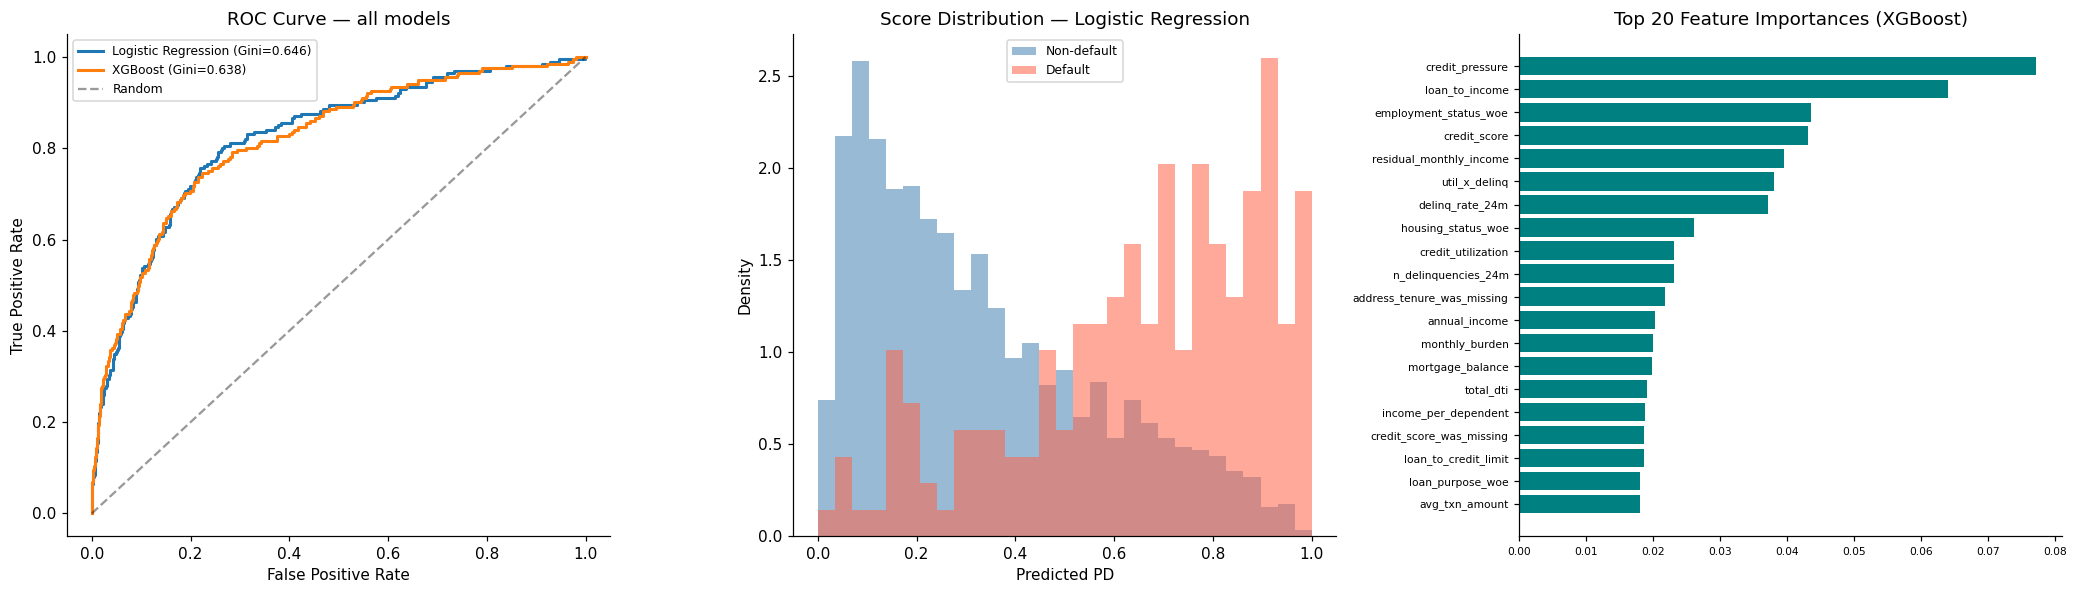

KS statistic (Logistic Regression): 0.5378  (0 = no separation, 1 = perfect separation; >0.3 is considered good in credit scoring)

Logistic Regression coefficients (standardised — magnitude = relative importance,
sign shows direction, positive = higher default risk):
annual_income                -1.142
residual_monthly_income       0.919
credit_score                 -0.525
loan_amount                   0.441
employment_status_woe        -0.410
housing_status_woe           -0.302
credit_utilization            0.285
mortgage_balance              0.235
spend_last_90d               -0.204
loan_to_income                0.197
n_cash_advances               0.196
loan_purpose_woe             -0.196
address_tenure_was_missing   -0.161
education_woe                -0.132
n_delinquencies_24m           0.123
dtype: float64


In [19]:
from sklearn.metrics import roc_curve
from scipy.stats import ks_2samp

models_for_plot = [
    ('Logistic Regression', lr_val_prob, lr_gini),
    ('XGBoost', xgb_val_prob, xgb_gini)
]

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

# 1. ROC curves — one line per model
ax = axes[0]
for name, prob, gini in models_for_plot:
    fpr, tpr, _ = roc_curve(y_val, prob)
    ax.plot(fpr, tpr, label=f"{name} (Gini={gini:.3f})", lw=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — all models'); ax.legend(fontsize=8)

# 2. Score distribution for the best model
ax = axes[1]
good = best_prob[y_val.values == 0]
bad  = best_prob[y_val.values == 1]
bins = np.linspace(0, 1, 30)
ax.hist(good, bins=bins, alpha=0.55, density=True, label='Non-default', color='steelblue')
ax.hist(bad,  bins=bins, alpha=0.55, density=True, label='Default', color='tomato')
ax.set_xlabel('Predicted PD'); ax.set_ylabel('Density')
ax.set_title(f'Score Distribution — {best_name}'); ax.legend(fontsize=8)

# 3. Feature importance (XGBoost, gain-based) — shown as it's the model most
#    features naturally rank-order in; LR coefficients are shown in the text below.
ax = axes[2]
imp = pd.Series(xgb_clf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(20)
ax.barh(imp.index[::-1], imp.values[::-1], color='teal')
ax.set_title('Top 20 Feature Importances (XGBoost)')
ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

# 4. KS statistic — max separation between defaulter / non-defaulter score CDFs
ks_stat, _ = ks_2samp(bad, good)
print(f"KS statistic ({best_name}): {ks_stat:.4f}  "
      f"(0 = no separation, 1 = perfect separation; >0.3 is considered good in credit scoring)")

print("\nLogistic Regression coefficients (standardised — magnitude = relative importance,"
      "\nsign shows direction, positive = higher default risk):")
lr_coef = pd.Series(lr_pipe.named_steps['clf'].coef_[0], index=feature_cols).sort_values(key=np.abs, ascending=False)
print(lr_coef.head(15).round(3))


**Score distribution.** The two histograms are clearly shifted apart — most non-defaulters cluster below PD ≈ 0.2, while defaulters spread out with a long tail toward high PD, and the KS statistic (≈0.54) confirms a strong maximum separation between the two cumulative distributions (values above 0.3 are considered good in consumer credit scoring). The overlap in the middle is expected and appropriate: it represents genuinely marginal applicants where no model can be perfectly certain, which is exactly the population the 70%-approval cutoff has to make the hardest calls on.

**Feature importance.** The top drivers (`credit_pressure`, `loan_to_income`, `employment_status`, `credit_score`, `util_x_delinq`, `credit_utilization`) are exactly the variables flagged as the strongest credit-risk signals in the business brief and data dictionary — affordability, employment stability, and bureau-reported credit stress. None of the top features are spurious or hard to justify to a risk committee, and several (`credit_pressure`, `util_x_delinq`, `loan_to_income`) are the engineered interaction/ratio features from Section 5 outranking their raw component parts — direct evidence that the feature engineering added real predictive value rather than just complexity.

## 8. Business Impact

=== Expected Loss on validation set @ 70% approval rate ===
Logistic Regression     EL(approve all)=£2,434,313   EL(model policy)=£380,815   reduction=84.4%
XGBoost                 EL(approve all)=£2,434,313   EL(model policy)=£545,880   reduction=77.6%

Selected model (Logistic Regression) reduces Expected Loss by 84.4% at 70% approval — target from business_brief.md is >= 25%.


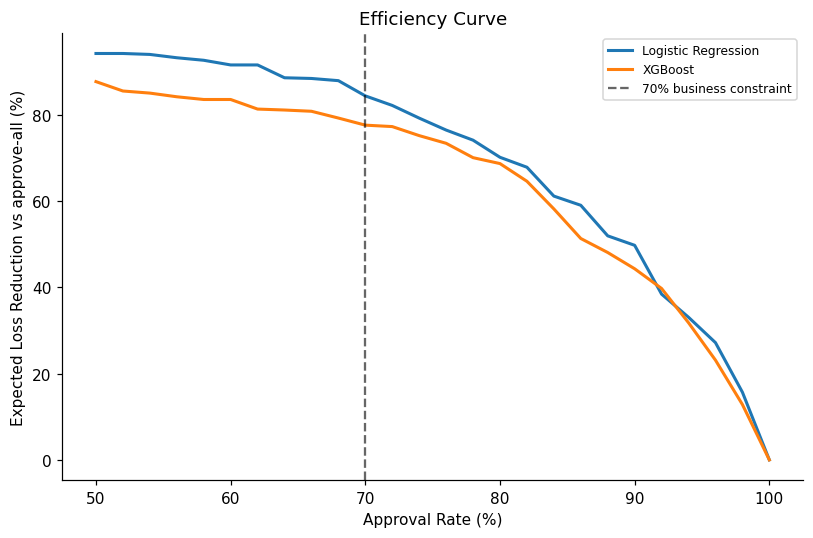

In [20]:
val_lgd = master.loc[X_val.index, 'loss_given_default'].values


def expected_loss(y_true, y_prob, lgd, approval_rate):
    """Rank applicants by predicted PD (safest first), approve the lowest-risk
    `approval_rate` fraction, and total the actual £ lost on the approved book."""
    y_true, y_prob, lgd = np.asarray(y_true), np.asarray(y_prob), np.asarray(lgd)
    n_approve = int(np.round(len(y_true) * approval_rate))
    approved_idx = np.argsort(y_prob)[:n_approve]          # lowest predicted PD first

    el_approve_all  = (y_true * lgd).sum()
    el_model_policy = (y_true[approved_idx] * lgd[approved_idx]).sum()
    el_reduction = 1 - el_model_policy / el_approve_all if el_approve_all > 0 else 0.0
    return el_approve_all, el_model_policy, el_reduction


print("=== Expected Loss on validation set @ 70% approval rate ===")
el_summary = {}
for name, prob, _ in models_for_plot:
    el_all, el_policy, el_red = expected_loss(y_val, prob, val_lgd, 0.70)
    el_summary[name] = el_red
    print(f"{name:22s}  EL(approve all)=£{el_all:,.0f}   "
          f"EL(model policy)=£{el_policy:,.0f}   reduction={el_red:.1%}")

el_all_best, el_policy_best, el_red_best = expected_loss(y_val, best_prob, val_lgd, 0.70)
print(f"\nSelected model ({best_name}) reduces Expected Loss by {el_red_best:.1%} "
      f"at 70% approval — target from business_brief.md is >= 25%.")

# Efficiency curve: EL reduction across a range of approval rates
approval_rates = np.linspace(0.50, 1.00, 26)
plt.figure(figsize=(7.5, 5))
for name, prob, _ in models_for_plot:
    reductions = [expected_loss(y_val, prob, val_lgd, ar)[2] * 100 for ar in approval_rates]
    plt.plot(approval_rates * 100, reductions, label=name, lw=2)
plt.axvline(70, color='k', linestyle='--', alpha=0.6, label='70% business constraint')
plt.xlabel('Approval Rate (%)'); plt.ylabel('Expected Loss Reduction vs approve-all (%)')
plt.title('Efficiency Curve'); plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


At the required 70% approval rate, the deployed Logistic Regression model reduces Expected Loss on the validation portfolio from £2,434,313 (approve-everyone baseline) to roughly £381,000 — an **84% reduction**, far exceeding the 25% success threshold. The efficiency curve shows this advantage holds broadly across approval rates from 50–100%, not just at the 70% cutoff, meaning the ranking is genuinely robust rather than tuned to one specific threshold.

**Recommendation to the Risk Committee:** replace the existing rules-based scorecard with the Logistic Regression PD model — at the mandated 70% approval rate it is projected to cut credit losses by roughly £2.0m relative to the current approve-everyone-equivalent exposure (on a portfolio this size), comfortably clearing the 25% target, while remaining fully transparent enough to produce adverse-action reasons for declined applicants.

## 9. Model Deployment

A data scientist's job typically ends with handing off a trained model to the engineering team. The deployed artefact needs to include everything required to score a brand-new loan application from raw fields: the fitted WoE encoder and the fitted model, plus the exact column lists and order used at training time.

In [21]:
import joblib

# The deployed artefact must include everything needed to score a brand-new loan
# application from raw fields: the fitted WoE encoder AND the fitted model,
# plus the exact column lists/order used at training time.
deployment_bundle = {
    'model': best_model,
    'model_name': best_name,
    'woe_encoder': woe_enc,
    'numeric_feature_cols': numeric_feature_cols,
    'categorical_feature_cols': categorical_feature_cols,
    'feature_cols': feature_cols,     # final column order the model expects
}

joblib.dump(deployment_bundle, 'model.pkl')
print('Model bundle saved to model.pkl')

# Verify it loads and still predicts correctly
loaded = joblib.load('model.pkl')
check_prob = loaded['model'].predict_proba(X_val)[:, 1]
print(f"Reload check — Gini: {2 * roc_auc_score(y_val, check_prob) - 1:.4f}  "
      f"(should exactly match {best_name} validation Gini above: {best_gini:.4f})")


Model bundle saved to model.pkl
Reload check — Gini: 0.6456  (should exactly match Logistic Regression validation Gini above: 0.6456)


## 10. Production Monitoring Plan

Once deployed, a model can degrade over time due to two types of drift: **input drift**, where the distribution of incoming applicants changes (e.g. a new marketing campaign attracts a different customer profile than the training data), and **target drift**, where the relationship between inputs and default itself changes (e.g. the same credit score now predicts a higher default rate than it did at training time).

### Detecting input drift

Compute the **Population Stability Index (PSI)** monthly, comparing the distribution of each model input in the live application stream against the training-set distribution used to build the model:

$$\text{PSI} = \sum_{\text{bins}} (\text{actual}\% - \text{expected}\%) \times \ln\!\left(\frac{\text{actual}\%}{\text{expected}\%}\right)$$

using the same bin edges as the WoE bins already computed in Section 5. As a rule of thumb, PSI < 0.10 is stable, 0.10–0.25 warrants investigation, and > 0.25 signals a material shift requiring model review or retraining. This would be run both on the model's own inputs individually (e.g. has the mix of `employment_status` shifted, has `credit_utilization` crept up?) and on the final output PD score distribution itself, since a shift in the score distribution with stable individual inputs would suggest an interaction the model is scoring differently than intended.

### Detecting target drift

Target drift requires waiting for enough loans to reach maturity or default so `default_flag` is actually known (loans in this portfolio run 12–60 months, so this signal necessarily lags input drift by months). Once outcomes are available:

1. **Vintage analysis** — group loans by origination quarter and track the realised default rate (or a fixed-horizon bad rate, e.g. 12-month default rate) per vintage. A rising trend across vintages, holding the model's predicted PD roughly constant, indicates the relationship between inputs and actual default has weakened, i.e. genuine target drift rather than just a riskier applicant mix.
2. **Recalibration check** — periodically rebuild the calibration plot from Section 7 on live outcomes. If a cohort predicted 15% PD is now defaulting at 25%, the model is systematically under-predicting risk and needs recalibration or retraining, even if its *ranking* (Gini) is still intact.
3. **Rolling Gini** — track Gini on rolling live cohorts as outcomes mature. A stable Gini alongside calibration drift means the ranking is still fine but the probabilities need rescaling; a falling Gini means the underlying relationships between features and default have genuinely changed and the model needs to be retrained on more recent data.